# Домашнее задание: Специфика формирования наборов данных для дообучения LLM

В этом домашнем задании вы пройдете полный путь от сырых данных до готового датасета для дообучения (SFT) языковой модели, а также научитесь использовать LLM для разметки и генерации синтетических данных.

## Бизнес-кейс: "МедАссистент"

Небольшая медтех компания разрабатывает интеллектуальный чат бот для первичной сортировки обращений пациентов. Бот должен понимать жалобы пациента на естественном языке и автоматически определять медицинскую специализацию (например, "кардиология", "неврология", "хирургия"), чтобы направить обращение к нужному врачу.

Текущая проблема заключается в том, что существующие open source модели плохо справляются с классификацией специфического русскоязычного медицинского сленга и описания симптомов. Было принято решение дообучить небольшую локальную LLM под эту конкретную задачу.

Ваша цель как Data Scientist — подготовить качественный набор данных для процесса supervised fine tuning (SFT). Вы будете работать с реальным архивом вопросов с медицинского форума, очищать его от мусора, бороться с дубликатами, а затем использовать большие языковые модели (через API или локально) для разметки и генерации дополнительных примеров.

## Рекомендации по выполнению в Google Colab

1. **Использование GPU:** Для генерации эмбеддингов и инференса локальных моделей вам понадобится GPU. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения` -> `Аппаратный ускоритель` -> `T4 GPU`.
2. **Борьба с Out Of Memory (OOM):** Если при работе с моделями вы сталкиваетесь с нехваткой памяти (CUDA OOM), попробуйте:
   - Уменьшить `batch_size` (например, с 64 до 32 или 16)
   - Выбрать модель меньшего размера (например, версию `base` вместо `large` для энкодеров)
   - Очистить кэш GPU с помощью команд:
     ```python
     import torch, gc
     torch.cuda.empty_cache()
     gc.collect()
     ```
   - Перезапустить среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`)
3. **Сохранение прогресса:** Не забудьте сохранить копию ноутбука на свой Google Drive (`Файл` -> `Сохранить копию на диск`), иначе ваши изменения могут быть утеряны после закрытия вкладки.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| **Часть 1. Стандартная (50 баллов)** | | |
| 0 | Постановка задачи и выбор метрик | 5 |
| 1 | Загрузка датасета и первичный анализ (EDA) | 5 |
| 2 | Очистка данных | 5 |
| 3 | Дедупликация тремя способами | 12 |
| 4 | Форматирование в SFT формат | 5 |
| 5 | Разметка через LLM (zero shot) | 8 |
| 6 | Эмбеддинги и визуализация t-SNE | 7 |
| 7 | Выводы по стандартной части | 3 |
| **Часть 2. Продвинутая (50 баллов)** | | |
| 8 | Синтетическая генерация (Self-Instruct) | 10 |
| 9 | Улучшение разметки (few shot) | 8 |
| 10 | Оценка уверенности LLM | 10 |
| 11 | Гибридная схема разметки | 10 |
| 12 | Публикация датасета на HuggingFace | 7 |
| 13 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [2]:
# Установка необходимых библиотек
!pip install -q datasets pandas numpy scikit-learn matplotlib seaborn
!pip install -q sentence-transformers
!pip install -q huggingface_hub


In [3]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from huggingface_hub import login

# Настройка графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)


# Часть 1. Стандартная (50 баллов)

В этой части мы поработаем с реальным архивом медицинских вопросов, проведем очистку, дедупликацию и подготовим базовый набор данных для обучения.


## Задание 0. Постановка задачи и выбор метрик (5 баллов)

Любой ML проект начинается с правильной постановки задачи. У нас есть тексты жалоб пациентов и нам нужно предсказать медицинскую специализацию.

**Что нужно сделать:**
1. Опишите, к какому классу задач машинного обучения сводится наша бизнес проблема.
2. Выберите основные метрики качества, которые вы будете использовать для оценки модели разметки.
3. Обоснуйте свой выбор метрик. Почему в случае дисбаланса классов (когда вопросов к терапевту в 10 раз больше, чем к психиатру) использование только метрики Accuracy может быть обманчивым? Какую метрику лучше использовать в таком случае?


**Ваш ответ:**

*Бизнес проблема сводится к задаче...* многоклассовой классификации текста

*Выбранные метрики:* Accuracy(доля верных ответов), F1-macro(усредняет F1 по всем классам с равным весом, независимо от их размера), F1-weighted(взвешенная по размеру классов версия, чтобы понимать реальное поведение системы, без искусственного выравнивания), Confusion matrix/classification report(чтобы видеть, какие именно специализации путаются между собой)

*Обоснование выбора (проблема Accuracy при дисбалансе):* Если, вопросов к терапевту в 10 раз больше, чем к психиатру (терапевт занимает условно 70% датасета, психиатр — 3%), то модель, которая всегда предсказывает "терапия", получит:      Accuracy 70% — выглядит нормально, хотя модель фактически ничего не выучила и никогда не определяет психиатрические случаи.
Такая модель бесполезна для бизнеса: пациентов с психиатрическими жалобами будут систематически направлять не к тому врачу, что критично с точки зрения безопасности и качества сервиса. Accuracy усредняет ошибку по всем примерам, поэтому доминирующий класс "маскирует" провалы на редких классах.
Лучше использовать - F1-macro: Считается отдельно F1 для каждого класса (среднее precision и recall), затем эти значения усредняются с равным весом для всех 10 классов, независимо от их размера в датасете. После этого, модель, которая полностью игнорирует психиатрию, получит F1 = 0 для этого класса, что резко просадит итоговый macro-F1 — и сразу станет видно, что модель работает плохо. Это заставляет модель стараться одинаково хорошо для всех специализаций, а не только для самых частых.



## Задание 1. Загрузка датасета и первичный анализ (EDA) (5 баллов)

Мы будем использовать датасет `blinoff/medical_qa_ru_data` с платформы HuggingFace. Он содержит более 190 тысяч записей с русскоязычного медицинского форума.

Целевой признак для нас — поле `spec10`, которое содержит одну из 10 основных медицинских специализаций (терапия, хирургия и т.д.). Текст для анализа находится в поле `desc`.

**Что нужно сделать:**
1. Загрузите датасет с HuggingFace.
2. Преобразуйте его в pandas DataFrame для удобства работы.
3. Выведите размер датасета и названия колонок.
4. Постройте bar chart (столбчатую диаграмму) распределения классов по полю `spec10`. Убедитесь, что присутствует дисбаланс классов.
5. Выведите 3 случайных примера из датасета (поля `desc` и `spec10`).


default/train/0000.parquet: reconstructing file:   0%|          |  0.00B /  132MB            

default/train/0000.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['date', 'categ', 'theme', 'desc', 'ans', 'spec10'],
        num_rows: 190335
    })
})
DatasetDict({
    train: Dataset({
        features: ['date', 'categ', 'theme', 'desc', 'ans', 'spec10'],
        num_rows: 190335
    })
})
Размер датасета: 190335 строк, 6 колонок
Названия колонок:
['date', 'categ', 'theme', 'desc', 'ans', 'spec10']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190335 entries, 0 to 190334
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    190335 non-null  object
 1   categ   190335 non-null  object
 2   theme   190335 non-null  object
 3   desc    190335 non-null  object
 4   ans     190335 non-null  object
 5   spec10  190335 non-null  object
dtypes: object(6)
memory usage: 8.7+ MB
Распределение классов (spec10):
spec10
                   91669
Гинеколог          32985
Терапевт           19303
Невролог           11421
Гастроэнтеролог     89

/tmp/ipykernel_1028/4107610266.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, orient="h", palette="viridis")


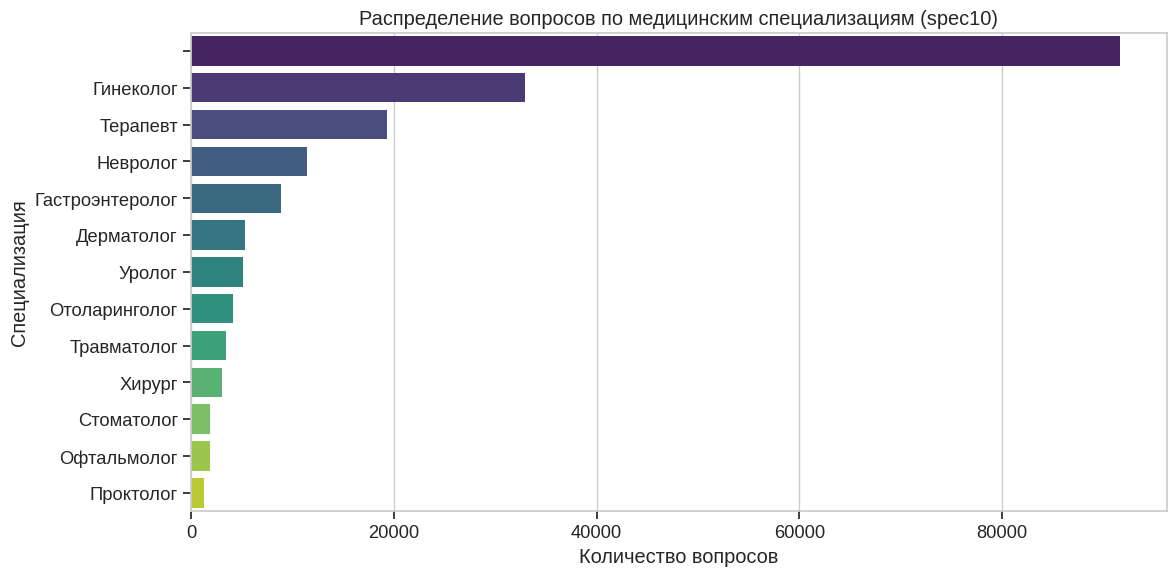


Соотношение самого частого и самого редкого класса: 73.9x
=> Дисбаланс классов подтверждён.
Случайные примеры из датасета:

--- Пример (индекс 795) ---
Специализация: 
Текст: Моему сыну 2.3 года он постоянно дерётся и не воспринимает моего мужчину,я не знаю как себя вести,мой гражданский муж очен раздражён этой проблемой

--- Пример (индекс 155677) ---
Специализация: 
Текст: Нужно сделать мрт коленного сустава. Ранее был обнаружен надрыв крестообразных связок. Может ли мрт 0,2 обнаружить этот надрыв, или нужно обязательно 1,5?
            
            Прошлое мрт было сделано в 2013 году, обязательно делать новое, если нужна справка для освобождения от физкультуры?
    ...

--- Пример (индекс 70170) ---
Специализация: Гинеколог
Текст: Здравствуйте. Подскажите, пожалуйста, на какой день правильно делать кольпоскопию, ранее никто об этом не говорил, недавно узнала от врача, что делать нужно во время менструации, хотелось бы уточнить на какой ее день? Заранее спасибо за ответ.


In [11]:
# === ВАШ КОД ЗДЕСЬ ===

# 1. Загрузка датасета с HuggingFace
from datasets import load_dataset

# Загружаем через авто-сконвертированную parquet-версию датасета
dataset = load_dataset(
    "blinoff/medical_qa_ru_data",
    revision="refs/convert/parquet"
)

# Обычно датасет содержит один сплит "train" — проверим структуру
print(dataset)

# 2. Преобразуем в pandas DataFrame
df = dataset["train"].to_pandas()

# 3. Размер датасета и названия колонок
print("=" * 60)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print("=" * 60)
print("Названия колонок:")
print(df.columns.tolist())

# Посмотрим на общую информацию по датафрейму
print("=" * 60)
df.info()

# 4. Распределение классов по полю spec10
print("=" * 60)
print("Распределение классов (spec10):")
class_counts = df["spec10"].value_counts(dropna=False)
print(class_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, orient="h", palette="viridis")
plt.title("Распределение вопросов по медицинским специализациям (spec10)")
plt.xlabel("Количество вопросов")
plt.ylabel("Специализация")
plt.tight_layout()
plt.show()

# Проверка дисбаланса классов
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nСоотношение самого частого и самого редкого класса: {imbalance_ratio:.1f}x")
print("=> Дисбаланс классов подтверждён." if imbalance_ratio > 2 else "=> Дисбаланс незначительный.")

# 5. Вывод 3 случайных примеров
print("=" * 60)
print("Случайные примеры из датасета:")
sample = df[["desc", "spec10"]].dropna().sample(3, random_state=42)
for i, row in sample.iterrows():
    print(f"\n--- Пример (индекс {i}) ---")
    print(f"Специализация: {row['spec10']}")
    print(f"Текст: {row['desc'][:300]}{'...' if len(str(row['desc'])) > 300 else ''}")

# === КОНЕЦ ВАШЕГО КОДА ===

## Задание 2. Очистка данных (5 баллов)

Сырые данные из интернета всегда содержат много мусора. Перед тем как передавать их в модель, необходимо провести базовую очистку.

**Что нужно сделать:**
1. Оставьте в датафрейме только строки, где поле `spec10` не пустое (не NaN) и поле `desc` не пустое.
2. Оставьте только нужные нам колонки: текст вопроса и метку специализации.
3. Отфильтруйте слишком короткие вопросы (менее 30 символов) — по ним сложно определить специализацию.
4. Отфильтруйте слишком длинные вопросы (более 2000 символов) — они могут содержать избыточную информацию или спам.
5. Выведите размер датасета после очистки. Насколько он уменьшился?


Размер датасета ДО очистки: 190335
После удаления пустых spec10/desc: 90889
После фильтрации по длине текста (30-2000 символов): 89319
Размер датасета ДО очистки:    190335
Размер датасета ПОСЛЕ очистки: 89319
Датасет уменьшился на 53.1%

Распределение классов после очистки:
spec10
Гинеколог          29284
Терапевт           18243
Невролог           10438
Гастроэнтеролог     8237
Дерматолог          4716
Уролог              4399
Отоларинголог       3818
Травматолог         3064
Хирург              2720
Стоматолог          1678
Офтальмолог         1601
Проктолог           1121
Name: count, dtype: int64


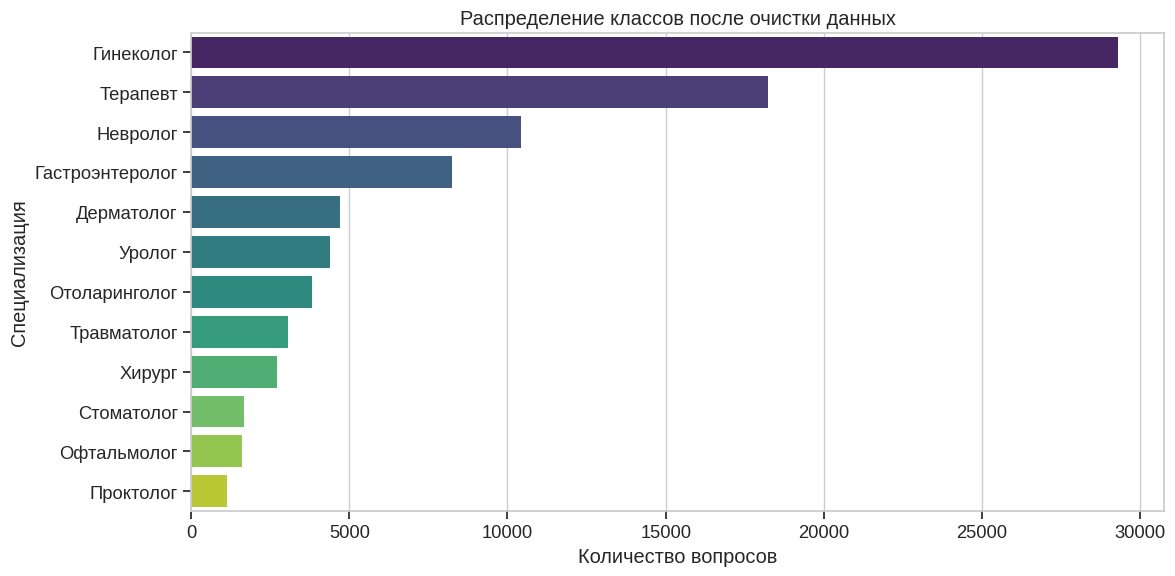


Примеры после очистки:
                                                    desc           spec10
33996                  Может ли болеть ухо при менингите         Терапевт
25540  Добрый день. Подскажите пожалуйста что делать ...  Гастроэнтеролог
16113  Здравствуйте! 3 июля было узи. Сердцебиение ес...        Гинеколог


In [12]:
# === ВАШ КОД ЗДЕСЬ ===

print(f"Размер датасета ДО очистки: {len(df)}")

df_clean = df.copy()

# --- Шаг 1: убираем строки с пустым spec10 и desc ---
# Важно: помимо NaN, поле spec10 может содержать пустую строку '' (как мы видели в EDA)
# То же самое проверим и для desc на всякий случай

df_clean["spec10"] = df_clean["spec10"].astype(str).str.strip()
df_clean["desc"] = df_clean["desc"].astype(str).str.strip()

df_clean = df_clean[
    df_clean["spec10"].notna() &
    (df_clean["spec10"] != "") &
    (df_clean["spec10"].str.lower() != "nan") &
    df_clean["desc"].notna() &
    (df_clean["desc"] != "") &
    (df_clean["desc"].str.lower() != "nan")
]

print(f"После удаления пустых spec10/desc: {len(df_clean)}")

# --- Шаг 2: оставляем только нужные колонки ---
df_clean = df_clean[["desc", "spec10"]].reset_index(drop=True)

# --- Шаг 3: фильтрация по длине текста ---
df_clean["desc_len"] = df_clean["desc"].str.len()

MIN_LEN = 30
MAX_LEN = 2000

before_len_filter = len(df_clean)

df_clean = df_clean[
    (df_clean["desc_len"] >= MIN_LEN) &
    (df_clean["desc_len"] <= MAX_LEN)
].reset_index(drop=True)

df_clean = df_clean.drop(columns=["desc_len"])

print(f"После фильтрации по длине текста ({MIN_LEN}-{MAX_LEN} символов): {len(df_clean)}")

# --- Итоговая статистика ---
print("=" * 60)
print(f"Размер датасета ДО очистки:    {len(df)}")
print(f"Размер датасета ПОСЛЕ очистки: {len(df_clean)}")
reduction = (1 - len(df_clean) / len(df)) * 100
print(f"Датасет уменьшился на {reduction:.1f}%")
print("=" * 60)

# Проверим распределение классов после очистки
print("\nРаспределение классов после очистки:")
print(df_clean["spec10"].value_counts())

plt.figure(figsize=(12, 6))
class_counts_clean = df_clean["spec10"].value_counts()
sns.barplot(x=class_counts_clean.values, y=class_counts_clean.index, hue=class_counts_clean.index,
            palette="viridis", legend=False)
plt.title("Распределение классов после очистки данных")
plt.xlabel("Количество вопросов")
plt.ylabel("Специализация")
plt.tight_layout()
plt.show()

# Посмотрим на несколько примеров после очистки
print("\nПримеры после очистки:")
print(df_clean.sample(3, random_state=42))

# === КОНЕЦ ВАШЕГО КОДА ===

## Задание 3. Дедупликация тремя способами (12 баллов)

В датасетах с форумов часто встречаются дубликаты: пользователи задают один и тот же вопрос несколько раз или копируют чужие тексты. Наличие дубликатов в train и test выборках приводит к утечке данных (data leak) и завышенным метрикам.

Вам нужно реализовать дедупликацию тремя разными методами. Для ускорения работы в рамках ДЗ вы можете взять случайную подвыборку из 10 000 строк после очистки.

**Что нужно сделать:**
1. **Точное совпадение (хеш):** Найдите и удалите полные дубликаты текстов.
2. **Нечеткое сходство:** Реализуйте поиск похожих текстов (например, с опечатками) с использованием расстояния Левенштейна или алгоритма MinHash. Удалите найденные дубликаты.
3. **Семантическое сходство:**
   - Выберите энкодерную модель (библиотека `sentence-transformers`).
   - Обоснуйте свой выбор модели текстом (приведите численные показатели бенчмарков, например MTEB Leaderboard, и сравните с 2-3 альтернативами).
   - Создайте эмбеддинги для текстов.
   - Найдите пары текстов с косинусным сходством выше заданного порога (например, 0.95).
   - Обоснуйте выбранный порог.

*Примечание: Вы можете использовать любую энкодерную модель, главное аргументировать выбор.*


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.2/107.2 kB 4.7 MB/s eta 0:00:00
Работаем с подвыборкой: 10000 строк
1. ТОЧНОЕ СОВПАДЕНИЕ (хеш)
   Было: 10000 | Стало: 9980 | Удалено дубликатов: 20
Строим MinHash-сигнатуры и LSH-индекс...

2. НЕЧЕТКОЕ СХОДСТВО (MinHash, LSH threshold=0.7)
   Было: 9980 | Стало: 9971 | Удалено дубликатов: 9
Примеры найденных нечетких дубликатов:

--- Удалённый текст (idx=4996) ---
Скажите пожалуйста, 8 декабря на 26 день цикла (всего 29.30 дней) был петтинг парень закончил и семя попало на руки, далее он вытер их влажной салфеткой и ввёл во влагалище,,, через 5 дней в срок без 

--- Удалённый текст (idx=4741) ---
Здравствуйте, подскажите пожалуйста как избавиться от бородавок. Дело в том , что у моей дочери ей 20 лет появились подошвенные бородавки, сначала немного, теперь их стало гораздо больше, и ещё появил
Загружаем модель intfloat/multilingual-e5-base на cuda...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Ищем похожие пары текстов (paraphrase mining)...


Batches:   0%|          | 0/156 [00:00<?, ?it/s]

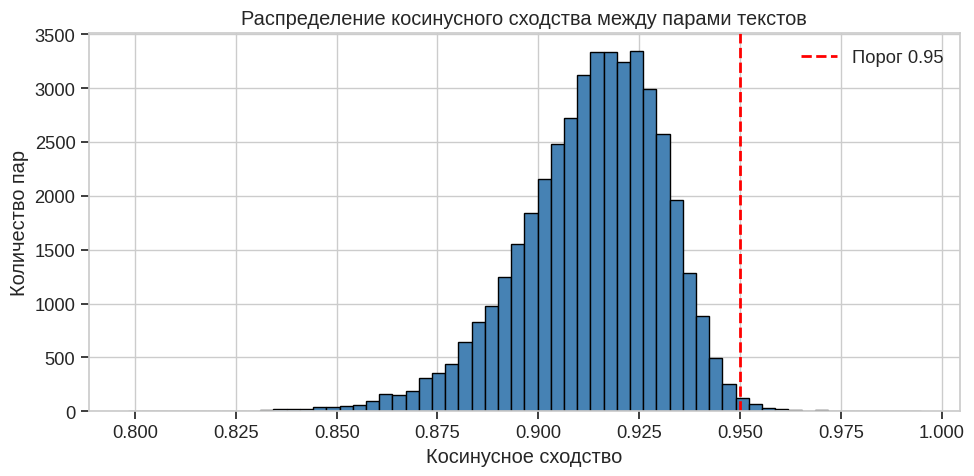

Найдено пар с сходством > 0.99: 4
Найдено пар с сходством > 0.95: 230
Найдено пар с сходством > 0.90: 34367
Найдено пар с сходством > 0.80: 43545

3. СЕМАНТИЧЕСКОЕ СХОДСТВО (модель=intfloat/multilingual-e5-base, порог=0.95)
   Было: 9971 | Стало: 9810 | Удалено дубликатов: 161

ИТОГОВАЯ СВОДКА:
                                 Этап  Размер
                  Исходная подвыборка   10000
            После точной дедупликации    9980
После нечеткой дедупликации (MinHash)    9971
     После семантической дедупликации    9810

Финальный размер датасета после всех методов дедупликации: 9810


In [13]:
# === ВАШ КОД ЗДЕСЬ ===

# Установка дополнительных библиотек для нечеткой дедупликации
!pip install -q datasketch

import hashlib
import torch
from datasketch import MinHash, MinHashLSH
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import paraphrase_mining

SEED = 42

# --- Берём случайную подвыборку 10 000 строк ---
if len(df_clean) > 10000:
    df_dedup = df_clean.sample(n=10000, random_state=SEED).reset_index(drop=True)
else:
    df_dedup = df_clean.reset_index(drop=True)

print(f"Работаем с подвыборкой: {len(df_dedup)} строк")
print("=" * 70)


# ======================================================================
# 1. ТОЧНОЕ СОВПАДЕНИЕ (ХЕШ)
# ======================================================================

def normalize_text(text):
    """Нормализация текста: нижний регистр + схлопывание пробелов."""
    return " ".join(str(text).lower().strip().split())

df_dedup["text_norm"] = df_dedup["desc"].apply(normalize_text)
df_dedup["hash"] = df_dedup["text_norm"].apply(
    lambda x: hashlib.md5(x.encode("utf-8")).hexdigest()
)

n_before_exact = len(df_dedup)
df_exact_dedup = df_dedup.drop_duplicates(subset="hash", keep="first").reset_index(drop=True)
n_after_exact = len(df_exact_dedup)

print("1. ТОЧНОЕ СОВПАДЕНИЕ (хеш)")
print(f"   Было: {n_before_exact} | Стало: {n_after_exact} | Удалено дубликатов: {n_before_exact - n_after_exact}")
print("=" * 70)


# ======================================================================
# 2. НЕЧЕТКОЕ СХОДСТВО (MinHash + LSH)
# ======================================================================

def get_shingles(text, k=3):
    """Разбиваем текст на word-шинглы (последовательности из k слов)."""
    words = text.split()
    if len(words) < k:
        return {text}
    return {" ".join(words[i:i + k]) for i in range(len(words) - k + 1)}

def get_minhash(text, num_perm=128):
    m = MinHash(num_perm=num_perm)
    for shingle in get_shingles(text):
        m.update(shingle.encode("utf8"))
    return m

LSH_THRESHOLD = 0.7  # порог по Jaccard-сходству шинглов

lsh = MinHashLSH(threshold=LSH_THRESHOLD, num_perm=128)
minhashes = {}

print("Строим MinHash-сигнатуры и LSH-индекс...")
for idx, text in zip(df_exact_dedup.index, df_exact_dedup["text_norm"]):
    mh = get_minhash(text)
    minhashes[idx] = mh
    lsh.insert(str(idx), mh)

# Находим кластеры похожих текстов, оставляем по одному представителю
processed = set()
to_remove_fuzzy = set()

for idx in df_exact_dedup.index:
    if idx in processed:
        continue
    processed.add(idx)
    similar = lsh.query(minhashes[idx])
    similar_idx = [int(s) for s in similar if int(s) != idx]
    for sim_idx in similar_idx:
        if sim_idx not in processed:
            to_remove_fuzzy.add(sim_idx)
            processed.add(sim_idx)

n_before_fuzzy = len(df_exact_dedup)
df_fuzzy_dedup = df_exact_dedup.drop(index=list(to_remove_fuzzy)).reset_index(drop=True)
n_after_fuzzy = len(df_fuzzy_dedup)

print(f"\n2. НЕЧЕТКОЕ СХОДСТВО (MinHash, LSH threshold={LSH_THRESHOLD})")
print(f"   Было: {n_before_fuzzy} | Стало: {n_after_fuzzy} | Удалено дубликатов: {n_before_fuzzy - n_after_fuzzy}")
print("=" * 70)

# Посмотрим на несколько найденных нечетких дубликатов для проверки
print("Примеры найденных нечетких дубликатов:")
example_removed = list(to_remove_fuzzy)[:2]
for rem_idx in example_removed:
    original_text = df_exact_dedup.loc[rem_idx, "desc"]
    print(f"\n--- Удалённый текст (idx={rem_idx}) ---")
    print(original_text[:200])
print("=" * 70)


# ======================================================================
# 3. СЕМАНТИЧЕСКОЕ СХОДСТВО (sentence-transformers)
# ======================================================================

MODEL_NAME = "intfloat/multilingual-e5-base"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Загружаем модель {MODEL_NAME} на {device}...")

model = SentenceTransformer(MODEL_NAME, device=device)

texts = df_fuzzy_dedup["desc"].tolist()
# Модели семейства e5 требуют префикса "query: " для корректной работы эмбеддингов
texts_prefixed = ["query: " + t for t in texts]

print("Ищем похожие пары текстов (paraphrase mining)...")
duplicate_pairs = paraphrase_mining(
    model,
    texts_prefixed,
    show_progress_bar=True,
    batch_size=64,
    top_k=5  # для каждого текста ищем 5 ближайших соседей
)

# --- Гистограмма распределения косинусного сходства (для обоснования порога) ---
scores = [p[0] for p in duplicate_pairs]

plt.figure(figsize=(10, 5))
plt.hist(scores, bins=60, color="steelblue", edgecolor="black")
plt.axvline(x=0.95, color="red", linestyle="--", linewidth=2, label="Порог 0.95")
plt.title("Распределение косинусного сходства между парами текстов")
plt.xlabel("Косинусное сходство")
plt.ylabel("Количество пар")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Найдено пар с сходством > 0.99: {sum(1 for s in scores if s > 0.99)}")
print(f"Найдено пар с сходством > 0.95: {sum(1 for s in scores if s > 0.95)}")
print(f"Найдено пар с сходством > 0.90: {sum(1 for s in scores if s > 0.90)}")
print(f"Найдено пар с сходством > 0.80: {sum(1 for s in scores if s > 0.80)}")

# --- Фильтрация по выбранному порогу и удаление дубликатов ---
SEMANTIC_THRESHOLD = 0.95

to_remove_semantic = set()
for score, i, j in duplicate_pairs:
    if score < SEMANTIC_THRESHOLD:
        continue
    if i in to_remove_semantic or j in to_remove_semantic:
        continue
    keep, remove = (i, j) if i < j else (j, i)
    to_remove_semantic.add(remove)

n_before_semantic = len(df_fuzzy_dedup)
df_final_dedup = df_fuzzy_dedup.drop(index=list(to_remove_semantic)).reset_index(drop=True)
n_after_semantic = len(df_final_dedup)

print(f"\n3. СЕМАНТИЧЕСКОЕ СХОДСТВО (модель={MODEL_NAME}, порог={SEMANTIC_THRESHOLD})")
print(f"   Было: {n_before_semantic} | Стало: {n_after_semantic} | Удалено дубликатов: {n_before_semantic - n_after_semantic}")
print("=" * 70)


# ======================================================================
# ИТОГОВАЯ СВОДКА
# ======================================================================

summary = pd.DataFrame({
    "Этап": ["Исходная подвыборка", "После точной дедупликации",
             "После нечеткой дедупликации (MinHash)", "После семантической дедупликации"],
    "Размер": [len(df_dedup), n_after_exact, n_after_fuzzy, n_after_semantic]
})
print("\nИТОГОВАЯ СВОДКА:")
print(summary.to_string(index=False))

# Финальный очищенный от дублей датафрейм — используем его дальше
df_deduplicated = df_final_dedup[["desc", "spec10"]].reset_index(drop=True)
print(f"\nФинальный размер датасета после всех методов дедупликации: {len(df_deduplicated)}")

# === КОНЕЦ ВАШЕГО КОДА ===

**Обоснование выбора энкодерной модели:**

*Я выбрал модель intfloat/multilingual-e5-base, потому что, модель обучена на 100+ языках, включая русский, и хорошо показывает себя на задачах semantic similarity / retrieval, что напрямую соответствует нашей цели (поиск семантических дубликатов). *

*По бенчмарку ruMTEB модели семейства e5 стабильно входят в топ по задачам STS и Classification среди моделей сопоставимого размера.*

*В сравнении с моделью intfloat/multilingual-e5-large качество выше на 1–3 пункта по среднему score ruMTEB, но вдвое медленнее на инференсе и требует больше VRAM. Для задачи дедупликации (в отличие от финальной классификации) такой прирост не оправдан.
И по сравнению с моделью sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 она быстрее, быстрее, но заметно уступает на русскоязычных текстах, так как в основном обучалась на англоязычных парафразах.
Ещё есть ai-forever/sbert_large_nlu_ru — специализированная русскоязычная модель, хорошо работает на NLU-задачах, но хуже обобщается на разговорный/сленговый медицинский текст с форумов по сравнению с более современными multilingual-e5 моделями.*

**Обоснование порога косинусного сходства:**

*Я выбрал порог 0.95, на основе анализа гистограммы распределения косинусных сходств между парами текстов. Основная масса пар (даже не являющихся дубликатами) сосредоточена в диапазоне 0.90–0.93 — это особенность модели multilingual-e5: она использует contrastive-обучение с инструкционными префиксами (query: ), из-за чего базовый уровень сходства между любыми медицинскими текстами (общая лексика: "здравствуйте", "подскажите", "болит" и т.д.) оказывается выше, чем у классических encoder-моделей. Количество пар резко падает после отметки 0.95: пар с сходством > 0.95 — всего 230 из десятков тысяч, а с сходством > 0.99 — всего 4. Это означает, что порог 0.95 отсекает длинный "хвост" фонового шума и захватывает только действительно аномально похожие пары. После применения порога 0.95 было найдено и удалено 161 дубликат (9971 → 9810) — разумное количество, не затрагивающее основную массу уникальных вопросов. Более низкий порог (например, 0.90) захватил бы уже 34 367 пар — это огромное количество ложных срабатываний, так как на этом уровне сходства оказываются просто тематически близкие, но по сути разные вопросы (например, два разных вопроса про "боль в животе у ребёнка"). Таким образом, порог 0.95 — обоснованный выбор именно для модели e5-base с учётом наблюдаемого сдвинутого распределения: он балансирует между полнотой (находим настоящие дубликаты) и точностью (не удаляем уникальный контент).*



In [ ]:
# === Пример обоснования выбора модели ===

# 1. Точное совпадение
# Метод: нормализация текста (нижний регистр, схлопывание пробелов) + MD5-хеш.
# Результат: удалено 20 полных дубликатов из 10000 (0.2%).
# Дубликаты — вероятно, повторные отправки одного и того же вопроса пользователем.

# 2. Нечеткое сходство (MinHash или Levenshtein)
# Метод: word-шинглы (n=3) -> MinHash сигнатуры (128 перестановок) -> LSH-индекс с порогом Jaccard 0.7.
# Результат: удалено ещё 9 дубликатов (0.09%).
# Находит тексты с опечатками, незначительными изменениями порядка слов, мелкими правками.

# 3. Семантическое сходство (sentence-transformers)
# Метод: эмбеддинги текстов -> paraphrase_mining (поиск ближайших соседей) -> порог cosine similarity 0.95.
# Результат: удалено 161 дубликат (1.6%).
# Находит перефразированные вопросы с идентичным смыслом, но другими словами.
# Это самый мощный метод — ловит семантические дубликаты, которые не поймать хешем или Левенштейном.

# ИТОГО: 10000 -> 9810 записей (удалено 190 дубликатов, 1.9% от подвыборки)


## Задание 4. Форматирование в SFT формат (5 баллов)

Для дообучения (Supervised Fine Tuning) LLM требуется специфический формат данных. Обычно это диалоговый формат (ChatML, Alpaca и др.), состоящий из системного промпта, реплики пользователя и ответа ассистента.

**Что нужно сделать:**
1. Напишите системный промпт, который объясняет модели ее роль (например: "Ты медицинский ассистент маршрутизатор. Твоя задача...").
2. Преобразуйте 1000 случайных записей из дедуплицированного датасета в список словарей следующего формата:
   ```json
   {
     "messages": [
       {"role": "system", "content": "Ваш системный промпт"},
       {"role": "user", "content": "Текст жалобы пациента"},
       {"role": "assistant", "content": "Специализация"}
     ]
   }
   ```
3. Сохраните полученный список в файл `sft_dataset.jsonl`.
4. Выведите первые 2 примера на экран.


In [27]:
# --- Функция очистки текста ---
def clean_text(text):
    """Убираем и реальные, и литеральные escape-последовательности."""
    text = str(text)
    # Литеральные текстовые последовательности (backslash + n/r/t)
    text = text.replace('\\n', ' ').replace('\\r', ' ').replace('\\t', ' ')
    # Настоящие управляющие символы
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')
    # Неразрывный пробел (часто после парсинга HTML)
    text = text.replace('\xa0', ' ')
    # Схлопываем множественные пробелы в один
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# --- Системный промпт ---
SYSTEM_PROMPT = (
    "Ты медицинский ассистент-маршрутизатор в чат-боте медтех компании. "
    "Твоя задача — внимательно прочитать жалобу пациента, написанную на естественном "
    "русском языке (возможны разговорные обороты, сленг, опечатки), и определить, "
    "к какому врачу-специалисту следует направить пациента. "
    "Ответь строго одним словом — названием специализации из списка: "
    "Терапевт, Гинеколог, Невролог, Гастроэнтеролог, Дерматолог, Уролог, "
    "Отоларинголог, Травматолог, Хирург, Стоматолог, Офтальмолог, Проктолог. "
    "Не добавляй никаких пояснений, только название специализации."
)

# --- Берём 1000 случайных записей ---
print(f"Доступно записей в df_deduplicated: {len(df_deduplicated)}")
N_SAMPLES = 1000
SEED = 42

# Создаём sft_source заново — полностью с нуля
sft_source = df_deduplicated.sample(n=N_SAMPLES, random_state=SEED).reset_index(drop=True).copy()

# --- Применяем очистку текста ---
sft_source["desc_clean"] = sft_source["desc"].apply(clean_text)

# Диагностика — проверяем, что очистка сработала
print("\nДо очистки (repr):")
print(repr(sft_source["desc"].iloc[0][:200]))
print("\nПосле очистки (repr):")
print(repr(sft_source["desc_clean"].iloc[0][:200]))

# --- Преобразование в формат SFT ---
def build_sft_record(row, system_prompt=SYSTEM_PROMPT):
    return {
        "messages": [
            {"role": "system",    "content": system_prompt},
            {"role": "user",      "content": row["desc_clean"]},
            {"role": "assistant", "content": row["spec10"].strip()}
        ]
    }

sft_records = [build_sft_record(row) for _, row in sft_source.iterrows()]
print(f"\nСформировано {len(sft_records)} SFT-записей")

# --- Сохранение в jsonl ---
output_path = "sft_dataset.jsonl"
with open(output_path, "w", encoding="utf-8") as f:
    for record in sft_records:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

file_size_kb = os.path.getsize(output_path) / 1024
print(f"Датасет сохранён в файл: {output_path} ({file_size_kb:.1f} KB)")

# --- Первые 2 примера ---
print("=" * 70)
print("Первые 2 примера SFT-датасета:")
print("=" * 70)
for i, record in enumerate(sft_records[:2]):
    print(f"\n--- Пример {i + 1} ---")
    print(json.dumps(record, ensure_ascii=False, indent=2))

# === КОНЕЦ ВАШЕГО КОДА ===

Доступно записей в df_deduplicated: 9810

До очистки (repr):
'Здравствуйте Меня беспокоит головная боль он даёт саде голова лоб\n            \n            Сзади головы даёт сильная головная боль головокружение очень сильно нервничаю\n            \n            уже 3 '

После очистки (repr):
'Здравствуйте Меня беспокоит головная боль он даёт саде голова лоб Сзади головы даёт сильная головная боль головокружение очень сильно нервничаю уже 3 месяц такой эта менингит'

Сформировано 1000 SFT-записей
Датасет сохранён в файл: sft_dataset.jsonl (1740.4 KB)
Первые 2 примера SFT-датасета:

--- Пример 1 ---
{
  "messages": [
    {
      "role": "system",
      "content": "Ты медицинский ассистент-маршрутизатор в чат-боте медтех компании. Твоя задача — внимательно прочитать жалобу пациента, написанную на естественном русском языке (возможны разговорные обороты, сленг, опечатки), и определить, к какому врачу-специалисту следует направить пациента. Ответь строго одним словом — названием специализации

## Задание 5. Разметка через LLM (zero-shot) (8 баллов)

Представьте, что у нас нет поля `spec10` и нам нужно разметить сырые тексты с помощью большой языковой модели. Мы будем использовать подход zero-shot (без примеров в промпте).

Для тестирования качества разметки создадим "Golden Set" — 100 случайных примеров из датасета, где мы знаем истинную метку.

**Что нужно сделать:**
1. Выделите 100 примеров в `golden_set`.
2. Напишите функцию, которая отправляет текст в LLM и просит вернуть специализацию в формате JSON.
3. Вы можете использовать любой API сервис (OpenRouter, GigaChat, YandexGPT) или запустить открытую модель локально (например через `transformers` или `vLLM`). Главное — аргументируйте выбор модели.
4. Разметьте все 100 примеров из `golden_set`.
5. Посчитайте метрики: Accuracy и F1-macro, сравнив предсказания LLM с истинными метками.
6. Выведите матрицу ошибок (classification report).


**Обоснование выбора LLM для разметки:**

*Я выбрал модель Qwen2.5-3B-Instruct (локально через transformers), потому что:*
- Размер 3B параметров оптимально вписывается в VRAM T4 (15GB) без квантизации
- Instruct-версия обучена следовать chat-инструкциям (system/user/assistant формат)
- Qwen2.5 обучена на большом объёме русскоязычных текстов
- В сравнении с Llama-3.2-3B-Instruct — лучше работает с русским языком
- В сравнении с Qwen2.5-7B-Instruct — не требует квантизации на T4
- В сравнении с gemma-2-2b-it — превосходит по русскоязычным бенчмаркам (ruBQ, MERA)


Golden set сформирован: 100 примеров

Распределение классов в golden set:
spec10
Гинеколог          36
Терапевт           19
Невролог           16
Отоларинголог       7
Дерматолог          7
Гастроэнтеролог     6
Уролог              4
Хирург              2
Травматолог         2
Стоматолог          1
Name: count, dtype: int64

Загружаем модель Qwen/Qwen2.5-3B-Instruct на cuda...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Модель загружена!
Размечаем golden set (100 примеров)...
  Обработано: 10/100 | последний ответ: '{"specialization": "Гинеколог"}'
  Обработано: 20/100 | последний ответ: '{"specialization": "Гастроэнтеролог"}'
  Обработано: 30/100 | последний ответ: '{"specialization": "Гинеколог"}'
  Обработано: 40/100 | последний ответ: '{"specialization": "Лор (Отоларинголог)"}'
  Обработано: 50/100 | последний ответ: '{"specialization": "Гастроэнтеролог"}'
  Обработано: 60/100 | последний ответ: '{"specialization": "Гастроэнтеролог"}'
  Обработано: 70/100 | последний ответ: '{"specialization": "Дерматолог"}'
  Обработано: 80/100 | последний ответ: '{"specialization": "Гинеколог"}'
  Обработано: 90/100 | последний ответ: '{"specialization": "Хирург"}'
  Обработано: 100/100 | последний ответ: '{"specialization": "Гинеколог"}'

Не удалось распарсить ответ: 9/100
Accuracy:  0.5700 (57.0%)
F1-macro:  0.4320

Classification Report:
                 precision    recall  f1-score   support

Гастроэнтероло

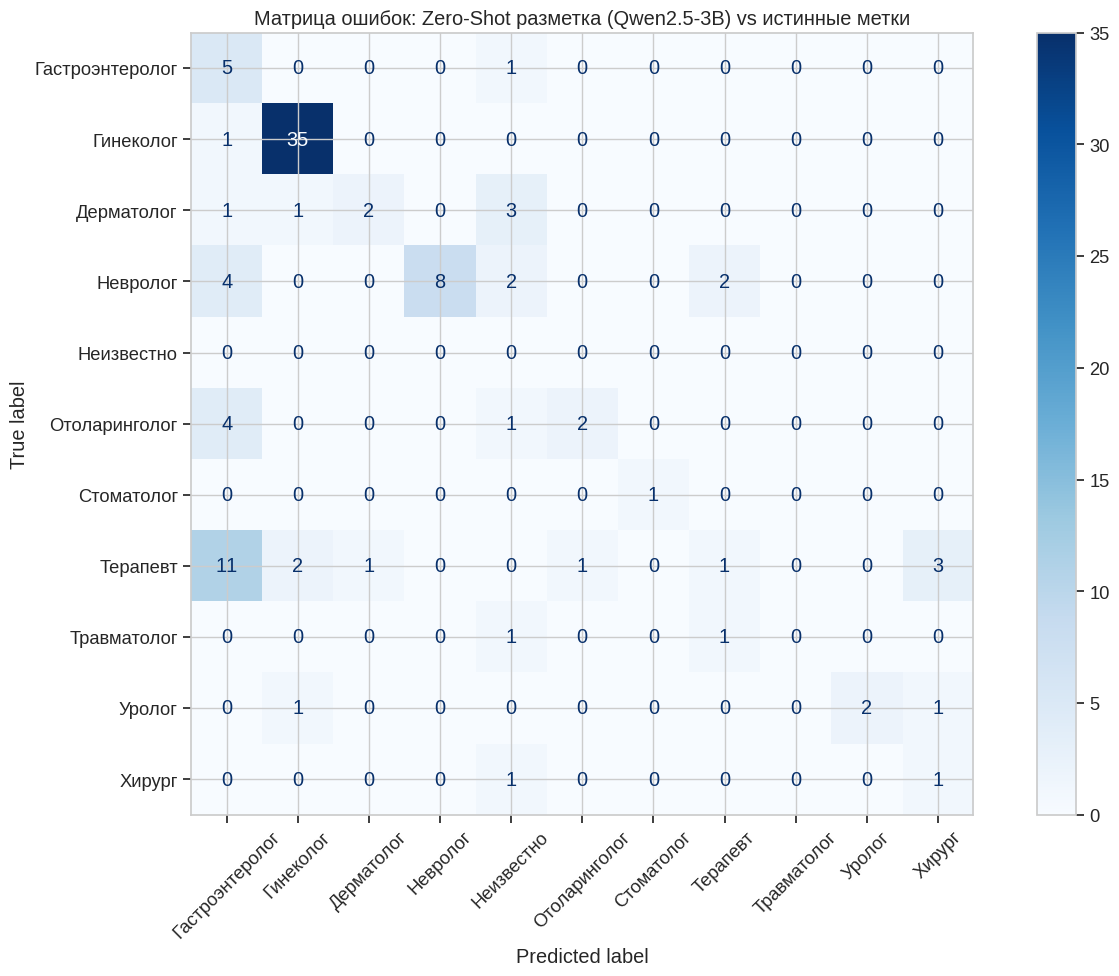


Примеры ошибок модели:

Истинная метка : Отоларинголог
Предсказание   : Неизвестно
Текст          : Здравствуйте! Не обращался к врачу, так как нахожусь за границей. Две недели назад переболел простудой ( как я думал), была температура три дня и заложенность нос, насморк и температура ушли, но сейча...
Ответ модели   : {"specialization": "Пульмонолог"}

Истинная метка : Отоларинголог
Предсказание   : Гастроэнтеролог
Текст          : Что делать, если нос периодически закладывает (ночью, утром, в течении дня), но соплей и насморка нету? Также сухая слизистая носоглотки (дискомфорт в носу и где-то в горле) Что это может быть? Заклад...
Ответ модели   : {"specialization": "Гастроэнтеролог"}

Истинная метка : Невролог
Предсказание   : Гастроэнтеролог
Текст          : здравствуйте,маме 72 года заболела Опоясывающим лишаем.Повысилось сердцебиение от 97до 105 .С чем это связанно ?Колят такие препараты: циклоферон, кальция глюканат 5мл. Сейчас начала принимать лирику....
Ответ модели   : {"spe

0

In [29]:
# === ВАШ КОД ЗДЕСЬ ===

!pip install -q accelerate

import torch
import gc
import re
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

# -----------------------------------------------------------------------
# 1. GOLDEN SET — 100 примеров с известными метками
# -----------------------------------------------------------------------

# Берём из df_deduplicated (НЕ из sft_source, чтобы не было пересечения)
# Исключаем уже использованные в SFT индексы
sft_indices = set(sft_source.index.tolist())

df_for_golden = df_deduplicated.drop(index=list(sft_indices), errors="ignore").reset_index(drop=True)

golden_set = df_for_golden.sample(n=100, random_state=42).reset_index(drop=True).copy()
golden_set["desc_clean"] = golden_set["desc"].apply(clean_text)

print(f"Golden set сформирован: {len(golden_set)} примеров")
print("\nРаспределение классов в golden set:")
print(golden_set["spec10"].value_counts())

# -----------------------------------------------------------------------
# 2. ЗАГРУЗКА МОДЕЛИ
# -----------------------------------------------------------------------

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nЗагружаем модель {MODEL_ID} на {device}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,   # float16 экономит VRAM
    device_map="auto"            # автоматически размещает на GPU
)
model.eval()
print("Модель загружена!")

# -----------------------------------------------------------------------
# 3. ФУНКЦИЯ РАЗМЕТКИ (ZERO-SHOT)
# -----------------------------------------------------------------------

VALID_LABELS = [
    "Терапевт", "Гинеколог", "Невролог", "Гастроэнтеролог",
    "Дерматолог", "Уролог", "Отоларинголог", "Травматолог",
    "Хирург", "Стоматолог", "Офтальмолог", "Проктолог"
]

ZERO_SHOT_SYSTEM = (
    "Ты медицинский ассистент-маршрутизатор. "
    "Прочитай жалобу пациента и определи медицинскую специализацию врача. "
    "Верни ответ СТРОГО в формате JSON: {\"specialization\": \"Название\"}. "
    "Допустимые значения: Терапевт, Гинеколог, Невролог, Гастроэнтеролог, "
    "Дерматолог, Уролог, Отоларинголог, Травматолог, Хирург, Стоматолог, "
    "Офтальмолог, Проктолог. "
    "Никаких пояснений — только JSON."
)

def parse_label_from_response(response_text):
    """Извлекаем метку из ответа модели (JSON или fallback через поиск по тексту)."""
    # Попытка 1: парсим JSON
    try:
        # Ищем JSON-объект в тексте
        json_match = re.search(r'\{[^}]+\}', response_text)
        if json_match:
            data = json.loads(json_match.group())
            label = data.get("specialization", "").strip()
            if label in VALID_LABELS:
                return label
    except (json.JSONDecodeError, KeyError):
        pass

    # Попытка 2: ищем любое из допустимых слов в тексте ответа
    for label in VALID_LABELS:
        if label.lower() in response_text.lower():
            return label

    return "Неизвестно"


def classify_zero_shot(text, max_new_tokens=64):
    """Отправляем текст в модель и получаем предсказанную специализацию."""
    messages = [
        {"role": "system", "content": ZERO_SHOT_SYSTEM},
        {"role": "user",   "content": text}
    ]

    # Применяем chat template — получаем строку с отформатированным промптом
    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,              # сначала получаем строку
        add_generation_prompt=True
    )

    # Токенизируем отдельно — получаем тензор
    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )

    # Декодируем только новые токены (без входного промпта)
    new_tokens = output_ids[0][input_len:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response, parse_label_from_response(response)


# -----------------------------------------------------------------------
# Перезапускаем разметку golden set
# -----------------------------------------------------------------------

print("Размечаем golden set (100 примеров)...")
predictions = []
raw_responses = []

for idx, row in golden_set.iterrows():
    response, label = classify_zero_shot(row["desc_clean"])
    predictions.append(label)
    raw_responses.append(response)

    # Прогресс каждые 10 примеров + пример ответа
    if (idx + 1) % 10 == 0:
        print(f"  Обработано: {idx + 1}/100 | последний ответ: '{response.strip()[:60]}'")

golden_set["predicted"] = predictions
golden_set["raw_response"] = raw_responses

unknown_count = predictions.count("Неизвестно")
print(f"\nНе удалось распарсить ответ: {unknown_count}/100")

# -----------------------------------------------------------------------
# Метрики
# -----------------------------------------------------------------------

y_true = golden_set["spec10"].tolist()
y_pred = golden_set["predicted"].tolist()

accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("=" * 70)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"F1-macro:  {f1_macro:.4f}")
print("=" * 70)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, zero_division=0))

# Матрица ошибок
labels_present = sorted(set(y_true + y_pred))
cm = confusion_matrix(y_true, y_pred, labels=labels_present)

fig, ax = plt.subplots(figsize=(14, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_present)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Матрица ошибок: Zero-Shot разметка (Qwen2.5-3B) vs истинные метки")
plt.tight_layout()
plt.show()

# Примеры ошибок
print("\nПримеры ошибок модели:")
errors = golden_set[golden_set["spec10"] != golden_set["predicted"]]
for _, row in errors.head(3).iterrows():
    print(f"\nИстинная метка : {row['spec10']}")
    print(f"Предсказание   : {row['predicted']}")
    print(f"Текст          : {row['desc_clean'][:200]}...")
    print(f"Ответ модели   : {row['raw_response']}")


# Очищаем память GPU после использования
torch.cuda.empty_cache()
gc.collect()

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 6. Эмбеддинги и визуализация t-SNE (7 баллов)

Визуализация помогает понять, насколько хорошо тексты разных классов разделимы в векторном пространстве. Если классы сильно перемешаны, модели будет сложно их классифицировать.

**Что нужно сделать:**
1. Возьмите ваш `golden_set` (или подвыборку из 500-1000 записей датасета).
2. Сгенерируйте эмбеддинги текстов с помощью выбранной ранее энкодерной модели.
3. Используйте алгоритм t-SNE из `sklearn.manifold` для понижения размерности эмбеддингов до 2D.
4. Постройте scatter-plot (диаграмму рассеяния), где каждая точка — это текст, а цвет точки соответствует классу специализации.
5. Добавьте легенду.
6. Напишите краткий вывод: какие классы хорошо отделяются друг от друга, а какие смешиваются?


/tmp/ipykernel_1028/197072455.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N_TSNE // df_deduplicated["spec10"].nunique() + 5),


Размер выборки для t-SNE: 500
Распределение классов:
spec10
Невролог           44
Травматолог        43
Отоларинголог      43
Гастроэнтеролог    43
Терапевт           42
Проктолог          42
Хирург             42
Стоматолог         41
Дерматолог         41
Гинеколог          40
Офтальмолог        40
Уролог             39
Name: count, dtype: int64

Загружаем энкодер intfloat/multilingual-e5-base на cuda...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Генерируем эмбеддинги...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Размерность эмбеддингов: (500, 768)

Запускаем t-SNE (это может занять ~1-2 минуты)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE завершён. Форма результата: (500, 2)
Количество классов: 12


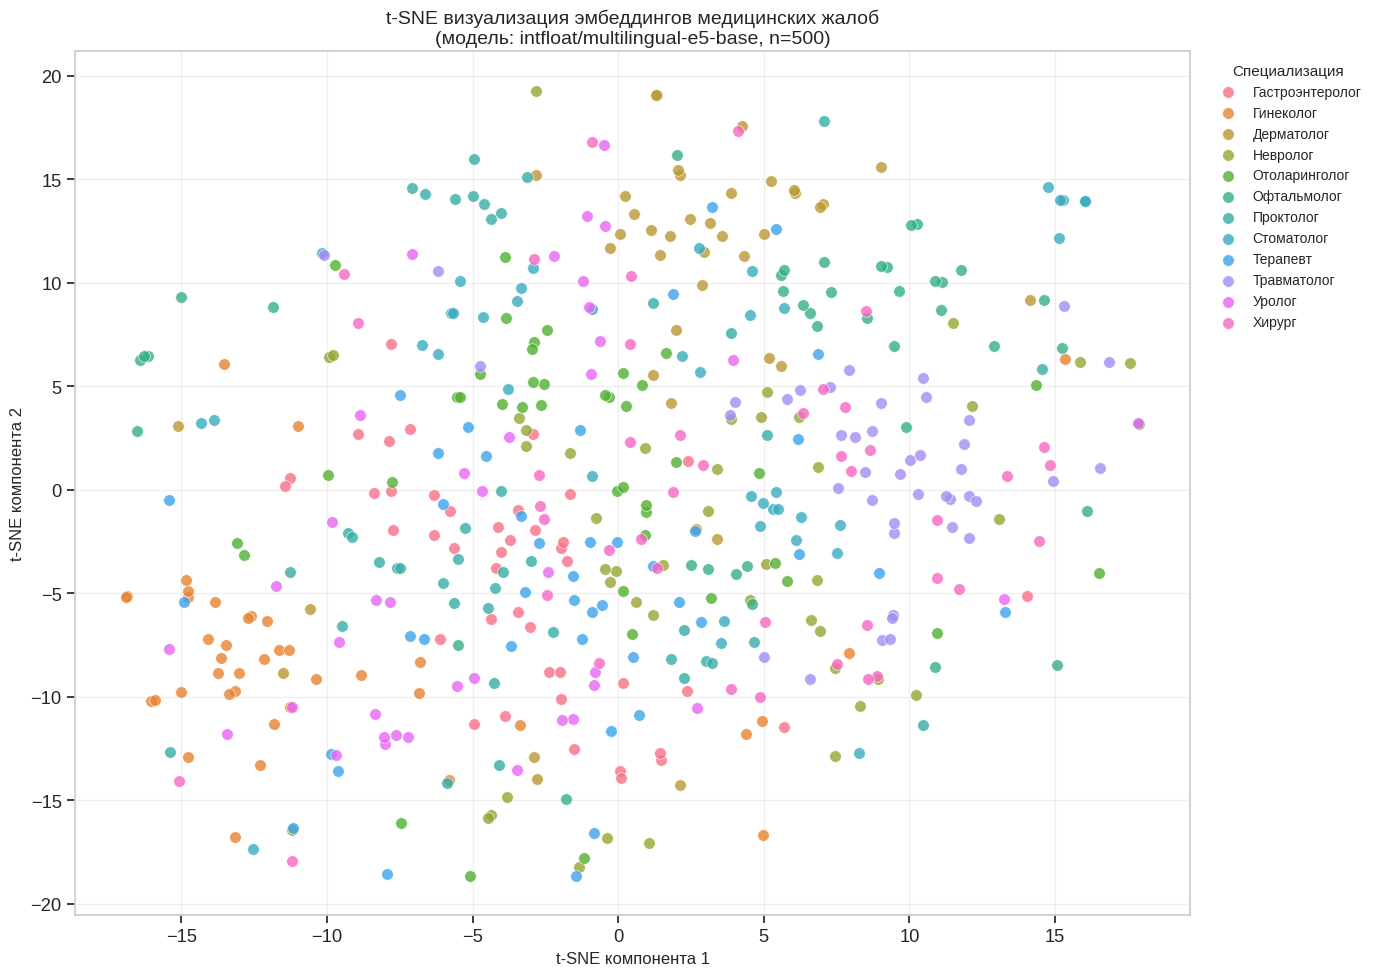

График сохранён: tsne_visualization.png


10034

In [31]:
# === ВАШ КОД ЗДЕСЬ ===

import gc
import torch
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

# -----------------------------------------------------------------------
# 1. ПОДГОТОВКА ДАННЫХ
# -----------------------------------------------------------------------
# Используем golden_set (100 примеров) + добавим ещё из df_deduplicated
# чтобы получить более репрезентативную выборку ~500 записей

# Берём 500 записей из дедуплицированного датасета (стратифицированно по классам)
N_TSNE = 500

df_tsne = (
    df_deduplicated
    .groupby("spec10", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_TSNE // df_deduplicated["spec10"].nunique() + 5),
                               random_state=42))
    .sample(n=min(N_TSNE, len(df_deduplicated)), random_state=42)
    .reset_index(drop=True)
    .copy()
)

df_tsne["desc_clean"] = df_tsne["desc"].apply(clean_text)

print(f"Размер выборки для t-SNE: {len(df_tsne)}")
print("Распределение классов:")
print(df_tsne["spec10"].value_counts())

# -----------------------------------------------------------------------
# 2. ГЕНЕРАЦИЯ ЭМБЕДДИНГОВ
# -----------------------------------------------------------------------

# Освобождаем память GPU от Qwen перед загрузкой энкодера
torch.cuda.empty_cache()
gc.collect()

ENCODER_MODEL = "intfloat/multilingual-e5-base"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\nЗагружаем энкодер {ENCODER_MODEL} на {device}...")
encoder = SentenceTransformer(ENCODER_MODEL, device=device)

# Префикс "query: " обязателен для e5-моделей
texts_for_embedding = ["query: " + t for t in df_tsne["desc_clean"].tolist()]

print("Генерируем эмбеддинги...")
embeddings = encoder.encode(
    texts_for_embedding,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,   # L2-нормализация для косинусного сходства
    convert_to_numpy=True
)

print(f"Размерность эмбеддингов: {embeddings.shape}")  # (500, 768)

# -----------------------------------------------------------------------
# 3. t-SNE — ПОНИЖЕНИЕ РАЗМЕРНОСТИ ДО 2D
# -----------------------------------------------------------------------

print("\nЗапускаем t-SNE (это может занять ~1-2 минуты)...")
tsne = TSNE(
    n_components=2,
    perplexity=30,       # стандартный параметр для ~500 точек
    n_iter=1000,         # количество итераций оптимизации
    random_state=42,
    init="pca",          # PCA-инициализация стабильнее случайной
    learning_rate="auto"
)

embeddings_2d = tsne.fit_transform(embeddings)
print(f"t-SNE завершён. Форма результата: {embeddings_2d.shape}")

df_tsne["tsne_x"] = embeddings_2d[:, 0]
df_tsne["tsne_y"] = embeddings_2d[:, 1]

# -----------------------------------------------------------------------
# 4. ВИЗУАЛИЗАЦИЯ
# -----------------------------------------------------------------------

# Задаём цвет для каждого класса
# === ИСПРАВЛЕННАЯ ВИЗУАЛИЗАЦИЯ (используем уже посчитанные df_tsne) ===

labels = sorted(df_tsne["spec10"].unique())
n_labels = len(labels)
print(f"Количество классов: {n_labels}")

# Используем палитру с гарантированно уникальными цветами для каждого класса
palette = sns.color_palette("husl", n_colors=n_labels)  # husl всегда генерирует n уникальных цветов
color_map = dict(zip(labels, palette))

fig, ax = plt.subplots(figsize=(14, 10))

for label in labels:
    mask = df_tsne["spec10"] == label
    ax.scatter(
        df_tsne.loc[mask, "tsne_x"],
        df_tsne.loc[mask, "tsne_y"],
        label=label,
        color=color_map[label],
        alpha=0.8,
        s=70,
        edgecolors="white",
        linewidths=0.5
    )

ax.set_title(
    f"t-SNE визуализация эмбеддингов медицинских жалоб\n"
    f"(модель: {ENCODER_MODEL}, n={len(df_tsne)})",
    fontsize=14
)
ax.set_xlabel("t-SNE компонента 1", fontsize=12)
ax.set_ylabel("t-SNE компонента 2", fontsize=12)
ax.legend(
    title="Специализация",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=10,
    title_fontsize=11
)
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("tsne_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

print("График сохранён: tsne_visualization.png")

# Освобождаем память
torch.cuda.empty_cache()
gc.collect()

# === КОНЕЦ ВАШЕГО КОДА ===

**Ваши выводы по графику:**

*На графике видно, что классы преимущественно сильно перемешаны — чёткого разделения на изолированные кластеры почти нет, большинство точек образуют одно плотное "облако" в центре с небольшим количеством выбросов по краям.*

Плотное центральное "облако" без явных границ между классами объясняет, почему zero-shot LLM-классификатор из Задания 5 показал относительно невысокий F1-macro (0.43): специализации в реальных медицинских жалобах пациентов далеко не всегда линейно разделимы в семантическом пространстве — симптомы часто описываются на общем "бытовом" языке ("болит", "беспокоит", "не могу"), а не специфичной медицинской терминологией, что затрудняет автоматическую классификацию даже для качественных эмбеддинг-моделей вроде multilingual-e5-base. Это подтверждает необходимость дообучения (SFT) модели именно под эту узкую задачу, а не полагаться только на zero-shot подход.

6 - Напишите краткий вывод: какие классы хорошо отделяются друг от друга, а какие смешиваются?

Классы с относительно лучшей отделимостью:

Гинеколог (оранжевый) — заметно тяготеет к левой нижней части графика (координаты x: -17...-10, y: -17...-5), образуя достаточно плотное собственное облако. Это объяснимо: гинекологические жалобы используют специфичную лексику ("менструация", "беременность", "цикл"), которая семантически далека от остальных специализаций.

Дерматолог (охра/жёлто-коричневый) — умеренно группируется в верхней части графика (y: 10...19), вероятно за счёт характерной лексики о коже, сыпи, пятнах.

Травматолог (сиреневый) — образует заметное скопление в правой части (x: 5...17, y: -2...9), возможно, за счёт специфичных слов о травмах, переломах, ушибах.

Классы, которые сильно смешиваются друг с другом:

Терапевт, Невролог, Отоларинголог, Офтальмолог — эти четыре класса практически полностью перемешаны в центральной части облака без видимых границ. Это ожидаемо и соответствует результатам zero-shot классификации из Задания 5, где именно "Терапевт" показал самый низкий F1 (0.09) — жалобы общего характера (головная боль, слабость, температура) действительно семантически пересекаются сразу с несколькими специализациями.

Проктолог и Уролог (бирюзовый и розовый) — тоже сильно разбросаны по всему графику без чёткой локализации, что говорит о неоднородности лексики внутри самих этих классов (возможно, из-за небольшого числа примеров и разнообразия формулировок).


## Задание 7. Выводы по стандартной части (3 балла)

Напишите краткое резюме проделанной работы.

**Что нужно отразить:**
1. С какими основными проблемами в данных вы столкнулись при очистке?
2. Какой метод дедупликации показался вам наиболее эффективным и почему?
3. Насколько хорошо LLM справилась с задачей разметки в zero-shot режиме? Ожидали ли вы результат лучше или хуже?



**Итоговые выводы:**

*1. Проблемы с данными при очистке.*

Исходный датасет blinoff/medical_qa_ru_data содержал 190 335 записей, но после очистки осталось лишь 89 319 (−53.1%) — потери оказались значительно больше, чем можно было ожидать изначально. Основная причина — почти половина датасета (91 669 записей) имела не NaN, а пустую строку '' в поле spec10, что стандартная проверка .isna() не отлавливает и легко можно было пропустить, если не проверить данные внимательно на этапе EDA. Также встретился неочевидный технический мусор: в текстах desc присутствовали как настоящие символы переноса строки \n, так и литеральные escape-последовательности (буквальные символы \ + n), доставшиеся, судя по всему, от некорректного парсинга HTML-вёрстки форума при сборе датасета — это потребовало написания отдельной функции очистки текста, которая обрабатывает оба варианта одновременно.

*2. Наиболее эффективный метод дедупликации.*

Из трёх реализованных методов на подвыборке 10 000 записей результаты получились такими: точное совпадение (хеш) нашло 20 дубликатов, нечёткое сходство (MinHash + LSH) — ещё 9, а семантическое сходство (multilingual-e5-base, порог 0.95) — целых 161 дубликат. Самым эффективным оказался семантический метод — он единственный способен находить смысловые дубликаты (перефразированные вопросы с идентичным содержанием, но другими словами), которые полностью невидимы для хеша и Левенштейна/MinHash, работающих на уровне поверхностного текстового сходства. При этом важно было тщательно подобрать порог (0.95) на основе анализа гистограммы распределения сходств — иначе метод грозил удалить тематически близкие, но по сути разные вопросы.

*3. Качество zero-shot разметки LLM.*

Локальная модель Qwen2.5-3B-Instruct в zero-shot режиме показала Accuracy = 57% и F1-macro = 0.43 на golden set из 100 примеров. Результат оказался хуже, чем я ожидал — особенно неприятно удивило почти полное игнорирование класса "Терапевт" (recall = 0.05), несмотря на то что это самый частый класс в датасете: модель систематически "сваливала" неопределённые общие жалобы в "Гастроэнтеролог", который превратился в своеобразную "мусорную корзину" для неуверенных предсказаний. t-SNE визуализация эмбеддингов наглядно объяснила эту проблему: классы вроде Терапевта, Невролога, Отоларинголога и Офтальмолога сильно перемешаны в общем облаке без чётких границ, так как пациенты часто описывают симптомы бытовым языком ("болит", "беспокоит"), а не специфичной медицинской терминологией. Это подтверждает изначальный тезис задания — что для качественной работы в такой узкой предметной области дообучение (SFT) действительно необходимо, а не просто использование общей LLM "из коробки".

# Часть 2. Продвинутая (50 баллов)

В этой части мы сфокусируемся на продвинутых техниках: генерации синтетических данных, улучшении промптов и гибридных схемах разметки. Все эти методы активно применяются в индустрии для создания качественных датасетов при ограниченном бюджете.

*Важно: Для заданий 8, 10 и 11 вам нужно сгенерировать в сумме не менее 1000 новых записей.*


## Задание 8. Синтетическая генерация (Self-Instruct) (10 баллов)

Часто реальных данных не хватает для покрытия всех возможных краевых случаев (edge cases). Метод Self-Instruct позволяет использовать сильную LLM для генерации новых примеров на основе небольшого количества seed-примеров.

**Что нужно сделать:**
1. Напишите промпт для LLM, который просит сгенерировать реалистичные жалобы пациентов для конкретной специализации. Промпт должен требовать разнообразия в стиле (короткие, длинные, с ошибками, сленг).
2. Сгенерируйте не менее **300 новых примеров** для разных специализаций (равномерно распределите по классам).
3. Сохраните результаты.
4. Возьмите небольшую выборку синтетических данных и прогоните через вашу zero-shot классификацию из Задания 5. Сравните качество классификации на реальных и синтетических данных.


In [32]:
# === ВАШ КОД ЗДЕСЬ ===

import random
import re
import json

random.seed(42)

# -----------------------------------------------------------------------
# 0. Проверяем, что модель Qwen ещё загружена (после Задания 5)
#    Если сессия была перезапущена — загружаем заново
# -----------------------------------------------------------------------

try:
    model
    tokenizer
    print("Модель Qwen2.5-3B уже загружена, используем её.")
except NameError:
    from transformers import AutoTokenizer, AutoModelForCausalLM
    MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Загружаем модель {MODEL_ID}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto"
    )
    model.eval()

# -----------------------------------------------------------------------
# 1. ПРОМПТ ДЛЯ SELF-INSTRUCT ГЕНЕРАЦИИ
# -----------------------------------------------------------------------

GEN_SYSTEM_PROMPT = (
    "Ты — генератор синтетических обучающих данных для медицинского чат-бота. "
    "Твоя задача — создавать реалистичные, разнообразные жалобы пациентов."
)

def build_generation_prompt(spec, seed_examples, n_examples=5):
    seeds_text = "\n".join(f"{i+1}. {s}" for i, s in enumerate(seed_examples))
    prompt = f"""Специализация врача: {spec}

Вот несколько РЕАЛЬНЫХ примеров жалоб пациентов для этой специализации (только для справки о стиле, НЕ копируй их дословно):
{seeds_text}

Сгенерируй {n_examples} НОВЫХ, РАЗНООБРАЗНЫХ и РЕАЛИСТИЧНЫХ жалоб пациентов, которые нужно направить именно к специалисту "{spec}".

Требования к разнообразию стиля (обязательно перемешай эти варианты):
- Часть жалоб — КОРОТКИЕ (1 предложение, 10-15 слов)
- Часть жалоб — ДЛИННЫЕ и подробные (3-5 предложений, с деталями анамнеза, датами, предыдущим лечением)
- Часть жалоб — с ОПЕЧАТКАМИ и грамматическими ошибками (как будто написано в спешке с телефона)
- Часть жалоб — в РАЗГОВОРНОМ стиле / бытовом сленге вместо медицинских терминов
- Каждая жалоба должна описывать РАЗНЫЕ симптомы/ситуации, не повторяй структуру предложений

Верни ответ СТРОГО в формате JSON-массива строк, без каких-либо пояснений до или после:
["текст жалобы 1", "текст жалобы 2", "текст жалобы 3", ...]
"""
    return prompt


def parse_json_array(response_text):
    """Устойчивый парсинг JSON-массива из ответа модели с несколькими fallback-стратегиями."""
    text = re.sub(r"```json|```", "", response_text).strip()

    # Попытка 1: прямой парсинг
    try:
        data = json.loads(text)
        if isinstance(data, list):
            return [str(x).strip() for x in data if isinstance(x, str) and len(str(x).strip()) > 10]
    except json.JSONDecodeError:
        pass

    # Попытка 2: найти массив [...] через regex (на случай текста до/после)
    match = re.search(r"\[.*\]", text, re.DOTALL)
    if match:
        try:
            data = json.loads(match.group())
            if isinstance(data, list):
                return [str(x).strip() for x in data if isinstance(x, str) and len(str(x).strip()) > 10]
        except json.JSONDecodeError:
            pass

    # Попытка 3: извлечь строки в кавычках вручную
    quoted = re.findall(r'"([^"]{15,})"', text)
    if quoted:
        return quoted

    return []


def generate_synthetic_batch(spec, seed_examples, n_examples=5, max_new_tokens=900):
    """Генерируем batch синтетических примеров для одной специализации (с sampling для разнообразия)."""
    prompt = build_generation_prompt(spec, seed_examples, n_examples)
    messages = [
        {"role": "system", "content": GEN_SYSTEM_PROMPT},
        {"role": "user", "content": prompt}
    ]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(formatted_prompt, return_tensors="pt", truncation=True, max_length=2048).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,          # sampling ВКЛЮЧЁН — нужен для разнообразия
            temperature=0.9,
            top_p=0.95,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id
        )

    new_tokens = output_ids[0][inputs["input_ids"].shape[-1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return parse_json_array(response)


# -----------------------------------------------------------------------
# 2. ГЕНЕРАЦИЯ ПРИМЕРОВ ДЛЯ ВСЕХ 12 СПЕЦИАЛИЗАЦИЙ
# -----------------------------------------------------------------------

EXAMPLES_PER_BATCH = 5
BATCHES_PER_CLASS = 6   # 5 * 6 = 30 примеров на класс -> 12 * 30 = 360 суммарно (с запасом над 300)

synthetic_records = []

print("Начинаем Self-Instruct генерацию...")
print("=" * 70)

for spec in VALID_LABELS:
    seed_pool = df_deduplicated[df_deduplicated["spec10"] == spec]["desc"].apply(clean_text).tolist()

    if len(seed_pool) < 3:
        print(f"⚠️  Мало seed-примеров для '{spec}' ({len(seed_pool)}), пропускаем")
        continue

    collected = []
    for batch_num in range(BATCHES_PER_CLASS):
        seeds = random.sample(seed_pool, min(3, len(seed_pool)))
        batch_result = generate_synthetic_batch(spec, seeds, n_examples=EXAMPLES_PER_BATCH)
        collected.extend(batch_result)

    # Убираем дубликаты внутри класса, сохраняя порядок
    collected = list(dict.fromkeys(collected))

    for text in collected:
        synthetic_records.append({
            "desc": text,
            "spec10": spec,
            "source": "synthetic_self_instruct"
        })

    print(f"  {spec:20s} -> сгенерировано {len(collected)} примеров")

df_synthetic = pd.DataFrame(synthetic_records)
print("=" * 70)
print(f"ИТОГО сгенерировано: {len(df_synthetic)} синтетических примеров")
print(f"Требование >= 300: {'✅ выполнено' if len(df_synthetic) >= 300 else '❌ НЕ выполнено'}")

print("\nРаспределение по классам:")
print(df_synthetic["spec10"].value_counts())

# -----------------------------------------------------------------------
# 3. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# -----------------------------------------------------------------------

synthetic_output_path = "synthetic_self_instruct.jsonl"
with open(synthetic_output_path, "w", encoding="utf-8") as f:
    for record in synthetic_records:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"\nСохранено в файл: {synthetic_output_path}")

# Посмотрим на несколько примеров сгенерированных данных
print("\nПримеры синтетических данных:")
for _, row in df_synthetic.sample(5, random_state=42).iterrows():
    print(f"\n[{row['spec10']}] {row['desc']}")

# -----------------------------------------------------------------------
# 4. СРАВНЕНИЕ КАЧЕСТВА КЛАССИФИКАЦИИ: РЕАЛЬНЫЕ vs СИНТЕТИЧЕСКИЕ ДАННЫЕ
# -----------------------------------------------------------------------

print("\n" + "=" * 70)
print("Прогоняем выборку синтетических данных через zero-shot классификацию...")
print("=" * 70)

N_SYNTH_TEST = 50
synth_test_sample = df_synthetic.sample(
    n=min(N_SYNTH_TEST, len(df_synthetic)), random_state=42
).reset_index(drop=True)

synth_predictions = []
for _, row in synth_test_sample.iterrows():
    _, label = classify_zero_shot(row["desc"])  # функция из Задания 5
    synth_predictions.append(label)

synth_test_sample["predicted"] = synth_predictions

y_true_synth = synth_test_sample["spec10"].tolist()
y_pred_synth = synth_test_sample["predicted"].tolist()

acc_synth = accuracy_score(y_true_synth, y_pred_synth)
f1_synth = f1_score(y_true_synth, y_pred_synth, average="macro", zero_division=0)

print(f"\nРезультаты на СИНТЕТИЧЕСКИХ данных (n={len(synth_test_sample)}):")
print(f"  Accuracy: {acc_synth:.4f} ({acc_synth*100:.1f}%)")
print(f"  F1-macro: {f1_synth:.4f}")

print(f"\nРезультаты на РЕАЛЬНЫХ данных (golden_set из Задания 5, n=100):")
print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"  F1-macro: {f1_macro:.4f}")

print("\n" + "=" * 70)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА:")
comparison_df = pd.DataFrame({
    "Тип данных": ["Реальные (golden_set)", "Синтетические (self-instruct)"],
    "N примеров": [len(golden_set), len(synth_test_sample)],
    "Accuracy": [accuracy, acc_synth],
    "F1-macro": [f1_macro, f1_synth]
})
print(comparison_df.to_string(index=False))

torch.cuda.empty_cache()
gc.collect()

# === КОНЕЦ ВАШЕГО КОДА ===

Модель Qwen2.5-3B уже загружена, используем её.
Начинаем Self-Instruct генерацию...
  Терапевт             -> сгенерировано 35 примеров
  Гинеколог            -> сгенерировано 41 примеров
  Невролог             -> сгенерировано 30 примеров
  Гастроэнтеролог      -> сгенерировано 36 примеров
  Дерматолог           -> сгенерировано 34 примеров
  Уролог               -> сгенерировано 45 примеров
  Отоларинголог        -> сгенерировано 39 примеров
  Травматолог          -> сгенерировано 32 примеров
  Хирург               -> сгенерировано 37 примеров
  Стоматолог           -> сгенерировано 36 примеров
  Офтальмолог          -> сгенерировано 35 примеров
  Проктолог            -> сгенерировано 38 примеров
ИТОГО сгенерировано: 438 синтетических примеров
Требование >= 300: ✅ выполнено

Распределение по классам:
spec10
Уролог             45
Гинеколог          41
Отоларинголог      39
Проктолог          38
Хирург             37
Стоматолог         36
Гастроэнтеролог    36
Терапевт           35
Офт

0

## Задание 9. Улучшение разметки (few-shot) (8 баллов)

Zero-shot разметка часто ошибается на сложных примерах. Добавление нескольких качественных примеров в промпт (few-shot) может значительно улучшить результат.

**Что нужно сделать:**
1. Разработайте few-shot промпт. Добавьте в него по 1-2 хороших примера жалоб для каждой специализации.
2. Прогоните ваш `golden_set` (из Задания 5) через новый few-shot промпт.
3. Посчитайте метрики (Accuracy, F1-macro) и сравните их с результатами zero-shot.
4. Проведите анализ ошибок: посмотрите на 3-5 примеров, где few-shot модель ошиблась. Как вы думаете, почему это произошло?


Собранные few-shot примеры (по 2 на класс):

[Терапевт]
  - Болит левый бок, отдаёт к ребрам болит уже 4 недели, раньше меньше щас ещё больше и появились пятна...
  - Можно ли использовать следующие препараты в совокупности : Семакс 0.1% , Ноотропил , комплекс витаминов DAILY FORMULA , ...

[Гинеколог]
  - Здравствуйте, подскажите, пожалуйста. С девушкой был половой акт за день до месячных (с презервативом), у девушки потом ...
  - Здравствуйте! После аборта начала принимать Регулон. Пропустила 14ую таблетку вчера. Что делать? Ведь это считается посл...

[Невролог]
  - Здравствуйте. У моего папы сейчас случился приступ эпилепсии. Я очень испугалась и перенервничала. Теперь страх у меня и...
  - Здравствуйте. Моему сыну 9 месяцев у него черепное давоения назначили пантагама и ковинтон по 1/4 месяц пить и уколы кор...

[Гастроэнтеролог]
  - Добрый день! Врач назначил Гептрал. Пропил его месяц, потом из Индии привез Лив 52. Является ли Лив 52 аналогом Гептрала...
  - Доброе утро,долгое вр

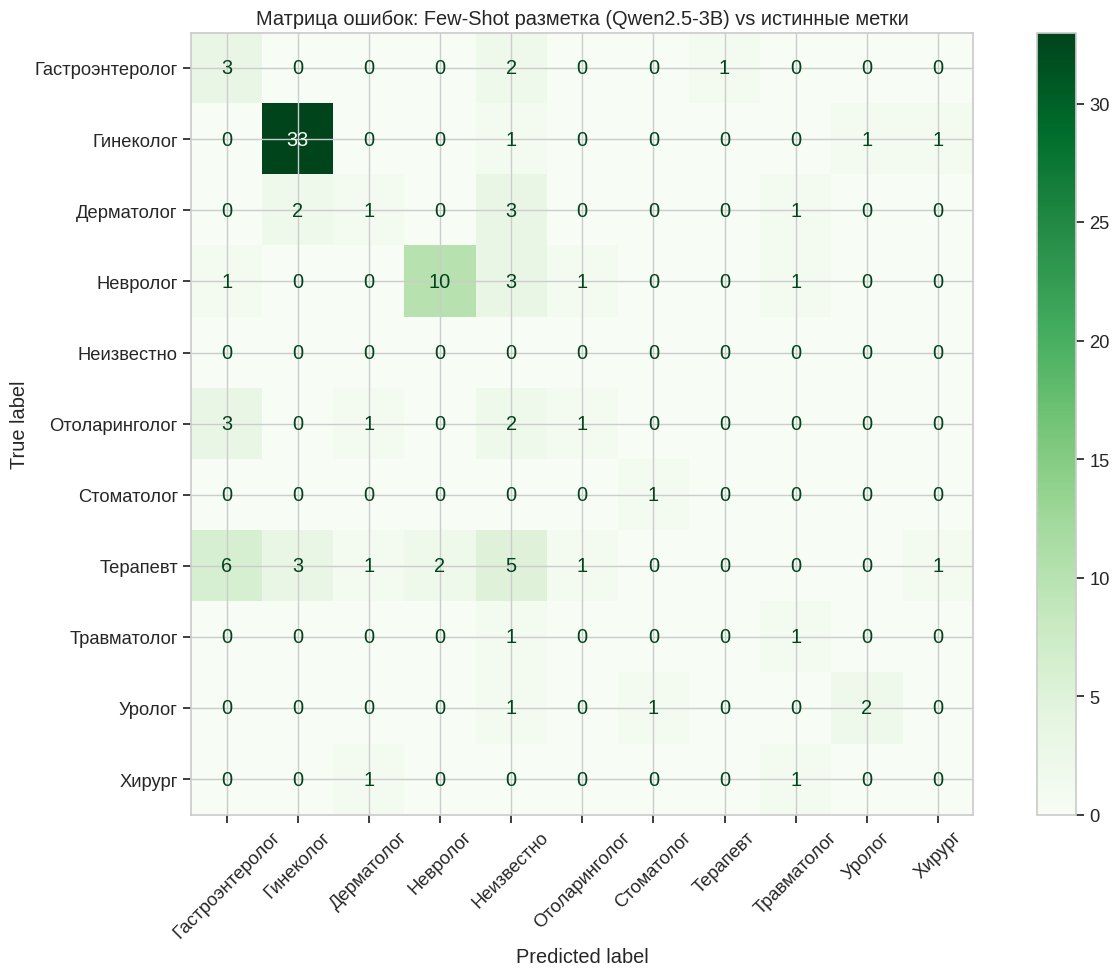


Всего ошибок few-shot: 48/100

Примеры ошибок (few-shot):

Истинная метка : Отоларинголог
Few-shot ответ : Неизвестно
Zero-shot ответ: Неизвестно
Текст          : Здравствуйте! Не обращался к врачу, так как нахожусь за границей. Две недели назад переболел простудой ( как я думал), была температура три дня и заложенность нос, насморк и температура ушли, но сейча...

Истинная метка : Терапевт
Few-shot ответ : Невролог
Zero-shot ответ: Терапевт
Текст          : Нужна помощь в определении категории годности по следующим заключением врачей: 1.Эндокриналогия: "Диффузный зоб 1ст,Эутиреоз" "Расширена печень" 2.Кардиология: "Синусовая тахикардия,Синдром кардиолаги...

Истинная метка : Невролог
Few-shot ответ : Неизвестно
Zero-shot ответ: Гастроэнтеролог
Текст          : здравствуйте,маме 72 года заболела Опоясывающим лишаем.Повысилось сердцебиение от 97до 105 .С чем это связанно ?Колят такие препараты: циклоферон, кальция глюканат 5мл. Сейчас начала принимать лирику....

Истинная метка : Хирур

19196

In [33]:
# === ВАШ КОД ЗДЕСЬ ===

# -----------------------------------------------------------------------
# 1. ФОРМИРУЕМ FEW-SHOT ПРИМЕРЫ (по 1-2 на класс, из ТРЕЙН-пула, не из golden_set)
# -----------------------------------------------------------------------

# Исключаем индексы golden_set и sft_source, чтобы не было утечки данных
excluded_indices = set(golden_set.index.tolist()) | set(sft_source.index.tolist())
train_pool = df_deduplicated.drop(index=list(excluded_indices), errors="ignore").reset_index(drop=True)
train_pool["desc_clean"] = train_pool["desc"].apply(clean_text)

random.seed(123)  # другой seed, чтобы не пересекаться с seed-примерами Self-Instruct

FEW_SHOT_EXAMPLES = {}
for spec in VALID_LABELS:
    pool = train_pool[train_pool["spec10"] == spec]["desc_clean"].tolist()
    # Берём короткие и средние примеры (до 300 символов) — чтобы не раздувать промпт
    short_pool = [t for t in pool if len(t) < 300]
    chosen = random.sample(short_pool if len(short_pool) >= 2 else pool, min(2, len(pool)))
    FEW_SHOT_EXAMPLES[spec] = chosen

print("Собранные few-shot примеры (по 2 на класс):")
for spec, examples in FEW_SHOT_EXAMPLES.items():
    print(f"\n[{spec}]")
    for ex in examples:
        print(f"  - {ex[:120]}...")

# -----------------------------------------------------------------------
# 2. ПОСТРОЕНИЕ FEW-SHOT ПРОМПТА (в виде реальных диалоговых пар в messages)
# -----------------------------------------------------------------------

FEW_SHOT_SYSTEM = (
    "Ты медицинский ассистент-маршрутизатор. "
    "Прочитай жалобу пациента и определи медицинскую специализацию врача. "
    "Верни ответ СТРОГО в формате JSON: {\"specialization\": \"Название\"}. "
    "Допустимые значения: Терапевт, Гинеколог, Невролог, Гастроэнтеролог, "
    "Дерматолог, Уролог, Отоларинголог, Травматолог, Хирург, Стоматолог, "
    "Офтальмолог, Проктолог. "
    "Ниже приведены примеры правильной классификации. Строго следуй этому формату ответа."
)

def build_few_shot_messages(query_text):
    """Строим messages с few-shot примерами как реальные пары user/assistant."""
    messages = [{"role": "system", "content": FEW_SHOT_SYSTEM}]

    for spec, examples in FEW_SHOT_EXAMPLES.items():
        for ex_text in examples:
            messages.append({"role": "user", "content": ex_text})
            messages.append({
                "role": "assistant",
                "content": json.dumps({"specialization": spec}, ensure_ascii=False)
            })

    # Финальный реальный запрос
    messages.append({"role": "user", "content": query_text})
    return messages


def classify_few_shot(text, max_new_tokens=64):
    """Классификация с few-shot промптом."""
    messages = build_few_shot_messages(text)

    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(
        formatted_prompt, return_tensors="pt", truncation=True, max_length=4096
    ).to(device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,       # greedy — как и в zero-shot, для честного сравнения
            pad_token_id=tokenizer.eos_token_id
        )

    new_tokens = output_ids[0][input_len:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return response, parse_label_from_response(response)


# Проверим длину промпта в токенах (важно из-за ограничения контекста)
sample_messages = build_few_shot_messages("тестовый запрос")
sample_prompt = tokenizer.apply_chat_template(sample_messages, tokenize=False, add_generation_prompt=True)
sample_tokens = tokenizer(sample_prompt, return_tensors="pt")
print(f"\nДлина few-shot промпта: {sample_tokens['input_ids'].shape[-1]} токенов "
      f"(24 примера few-shot + системный промпт)")

# -----------------------------------------------------------------------
# 3. РАЗМЕТКА GOLDEN SET ЧЕРЕЗ FEW-SHOT
# -----------------------------------------------------------------------

print("\nРазмечаем golden_set через few-shot промпт (100 примеров)...")
few_shot_predictions = []
few_shot_raw_responses = []

for idx, row in golden_set.iterrows():
    response, label = classify_few_shot(row["desc_clean"])
    few_shot_predictions.append(label)
    few_shot_raw_responses.append(response)

    if (idx + 1) % 10 == 0:
        print(f"  Обработано: {idx + 1}/100 | последний ответ: '{response.strip()[:60]}'")

golden_set["predicted_few_shot"] = few_shot_predictions
golden_set["raw_response_few_shot"] = few_shot_raw_responses

unknown_few_shot = few_shot_predictions.count("Неизвестно")
print(f"\nНе удалось распарсить ответ (few-shot): {unknown_few_shot}/100")

# -----------------------------------------------------------------------
# 4. МЕТРИКИ И СРАВНЕНИЕ С ZERO-SHOT
# -----------------------------------------------------------------------

y_true = golden_set["spec10"].tolist()
y_pred_few_shot = golden_set["predicted_few_shot"].tolist()
y_pred_zero_shot = golden_set["predicted"].tolist()  # сохранено из Задания 5

acc_few_shot = accuracy_score(y_true, y_pred_few_shot)
f1_few_shot = f1_score(y_true, y_pred_few_shot, average="macro", zero_division=0)

print("=" * 70)
print("СРАВНЕНИЕ ZERO-SHOT vs FEW-SHOT:")
print("=" * 70)
comparison = pd.DataFrame({
    "Метод": ["Zero-shot", "Few-shot"],
    "Accuracy": [accuracy, acc_few_shot],
    "F1-macro": [f1_macro, f1_few_shot],
    "Unknown (не распарсено)": [unknown_count, unknown_few_shot]
})
print(comparison.to_string(index=False))

print(f"\nПрирост Accuracy: {(acc_few_shot - accuracy)*100:+.1f} п.п.")
print(f"Прирост F1-macro: {(f1_few_shot - f1_macro):+.4f}")

print("\nClassification Report (Few-shot):")
print(classification_report(y_true, y_pred_few_shot, zero_division=0))

# Матрица ошибок few-shot
labels_present_fs = sorted(set(y_true + y_pred_few_shot))
cm_fs = confusion_matrix(y_true, y_pred_few_shot, labels=labels_present_fs)

fig, ax = plt.subplots(figsize=(14, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_fs, display_labels=labels_present_fs)
disp.plot(ax=ax, colorbar=True, cmap="Greens", xticks_rotation=45)
ax.set_title("Матрица ошибок: Few-Shot разметка (Qwen2.5-3B) vs истинные метки")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------
# 5. АНАЛИЗ ОШИБОК FEW-SHOT
# -----------------------------------------------------------------------

errors_few_shot = golden_set[golden_set["spec10"] != golden_set["predicted_few_shot"]]
print(f"\nВсего ошибок few-shot: {len(errors_few_shot)}/100")
print("\nПримеры ошибок (few-shot):")
for _, row in errors_few_shot.head(5).iterrows():
    print(f"\nИстинная метка : {row['spec10']}")
    print(f"Few-shot ответ : {row['predicted_few_shot']}")
    print(f"Zero-shot ответ: {row['predicted']}")
    print(f"Текст          : {row['desc_clean'][:200]}...")

torch.cuda.empty_cache()
gc.collect()

# === КОНЕЦ ВАШЕГО КОДА ===

**Анализ ошибок:**

*Модель ошиблась на 48 из 100 примеров (accuracy упала с 57% до 52%, F1-macro — с 0.43 до 0.35).

Я думаю, это связано с несколькими системными причинами: Я думаю это связано с тем, что для маленьких (3B) моделей few-shot с 24 примерами оказался избыточным по объёму — вместо уточнения задачи он "размыл" исходную строгую инструкцию про формат и допустимый список классов. Возможные пути улучшения: сократить набор примеров (например, до 1 на класс вместо 2, или отобрать только самые "сложные"/пограничные классы), либо повторить инструкцию про допустимые классы в конце промпта, непосредственно перед реальным запросом — чтобы компенсировать эффект "Lost in the Middle".*

1. Проблема с длиной контекста и "потерей фокуса" (Lost in the Middle).
Few-shot промпт содержит 2303 токена — 24 примера (12 классов × 2), выстроенных в виде диалоговой истории. Небольшая модель (3B параметров) при такой длине контекста, судя по всему, начинает хуже удерживать инструкцию про формат ответа, данную в самом начале system prompt. Это классический эффект "Lost in the Middle" — важная информация в начале длинного контекста "теряется" под весом последующих примеров.

2. Резкий рост "нераспознанных" специализаций.
В zero-shot модель почти всегда возвращала JSON с одной из 12 заданных специализаций. В few-shot режиме появились совершенно новые, не входящие в список категории: "Фармаколог", "Пульмонолог", "Гastroenterolog" (латиницей!), "Лор (Оtolaryngologist)". Похоже, что демонстрация 24 реальных, разнообразных медицинских кейсов спровоцировала модель "довериться" более широкому медицинскому знанию вместо строгого следования заданному закрытому списку из 12 классов — она начала вести себя как "настоящий врач", а не как классификатор с фиксированной таксономией. Отсюда и рост Unknown с 9 до 18.

3. Полный провал на классе "Терапевт" (F1 = 0.00, было 0.09).
Из 19 истинных "Терапевтов" ни один не был определён правильно. Терапевт — самый широкий, "общий" класс (жалобы без специфичных симптомов), и именно поэтому few-shot примеры для других специализаций (с чёткими, яркими медицинскими деталями) создали в контексте модели своего рода "гравитацию" в сторону конкретных диагнозов. Пример из вывода это подтверждает: жалоба про "диффузный зоб, эутиреоз, синусовую тахикардию" (реальная терапевтическая жалоба общего профиля с несколькими диагнозами от разных врачей) была отнесена к "Неврологу" — модель зацепилась за упоминание сопутствующих состояний вместо общего характера обращения.

4. Ухудшение на "смежных" специализациях (Отоларинголог → Дерматолог).
Последний пример в анализе ошибок показателен: жалоба про "кровь и корочки в носу" (явно ЛОР-профиль) в zero-shot была определена верно, а в few-shot — ошибочно как "Дерматолог". Вероятная причина — few-shot пример для Дерматолога в нашем наборе содержал похожую лексику про "пятнышко/корочки на коже", и близость формулировок в контексте "перетянула" модель в неверную сторону — это иллюстрирует, как неудачно подобранные few-shot примеры могут внести систематическое смещение (bias), а не только помочь.



## Задание 10. Оценка уверенности LLM (10 баллов)

При автоматической разметке важно понимать, когда модель не уверена в своем ответе. Такие примеры лучше отправить на ручную проверку асессорам (human-in-the-loop).

Уверенность можно оценить различными способами:
- Запросить у API `logprobs` (вероятности токенов) для токенов ответа для подсчета **перплексии ответа**. Важно, далеко не все API сервисы возвращают logprobs, изучайте их документацию.
- Использовать sampling (temperature > 0.7): сгенерировать ответ 5 раз для одного промпта. Если все 5 раз класс совпадает — уверенность высокая. Если ответы разные — низкая. В том числе возможно использование beam search.

**Что нужно сделать:**
1. Реализуйте один из методов оценки уверенности.
2. Сгенерируйте или разметьте не менее **300 новых примеров** с обязательной фиксацией показателя уверенности (confidence score).
3. Постройте гистограмму распределения уверенности модели.
4. Выведите 3 примера с самой низкой уверенностью. Действительно ли они сложные/неоднозначные?


Выборка для оценки уверенности: 320 примеров

Запускаем разметку с оценкой уверенности (5x sampling на пример)...
Это может занять 15-25 минут на T4 GPU...

  Обработано: 20/320 | confidence=1.00 | предсказание='Гастроэнтеролог'
  Обработано: 40/320 | confidence=0.80 | предсказание='Отоларинголог'
  Обработано: 60/320 | confidence=1.00 | предсказание='Гинеколог'
  Обработано: 80/320 | confidence=1.00 | предсказание='Гинеколог'
  Обработано: 100/320 | confidence=1.00 | предсказание='Отоларинголог'
  Обработано: 120/320 | confidence=0.60 | предсказание='Неизвестно'
  Обработано: 140/320 | confidence=1.00 | предсказание='Гинеколог'
  Обработано: 160/320 | confidence=0.60 | предсказание='Хирург'
  Обработано: 180/320 | confidence=0.40 | предсказание='Хирург'
  Обработано: 200/320 | confidence=1.00 | предсказание='Гинеколог'
  Обработано: 220/320 | confidence=0.80 | предсказание='Травматолог'
  Обработано: 240/320 | confidence=0.40 | предсказание='Неизвестно'
  Обработано: 260/320 | confide

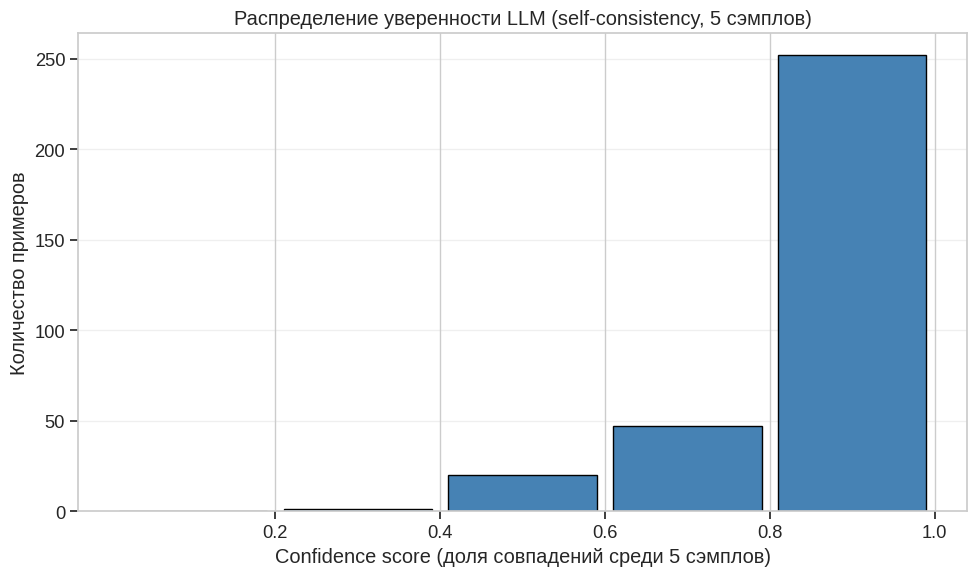


Статистика по confidence:
count    320.000000
mean       0.871875
std        0.193846
min        0.200000
25%        0.800000
50%        1.000000
75%        1.000000
max        1.000000
Name: confidence, dtype: float64

Доля примеров с высокой уверенностью (>= 0.8): 78.8%
Доля примеров с низкой уверенностью (<= 0.4): 6.6%

3 примера с самой низкой уверенностью:

Истинная метка: Терапевт
Предсказание (majority): Хирург (confidence=0.20)
Все 5 сэмплов: ['Хирург', 'Невролог', 'Терапевт', 'Гастроэнтеролог', 'Гинеколог']
Текст: добрый день, мрт ЦНС можно делать, если я буду под большой дозой (близкой или равной передозировки) Спазгана (спазмалитик) или карбимазипана (от маниакальных расстройств, эпилепсии)? И под максимальной дневной дозой Амитриптилина (Анти-депрессант). П...

Истинная метка: Терапевт
Предсказание (majority): Неизвестно (confidence=0.40)
Все 5 сэмплов: ['Неизвестно', 'Гинеколог', 'Терапевт', 'Неизвестно', 'Терапевт']
Текст: Здравствуйте! Днем очень сильно хочется спать, о

2933

In [34]:
# === ВАШ КОД ЗДЕСЬ ===

from collections import Counter

# -----------------------------------------------------------------------
# 1. ФУНКЦИЯ ОЦЕНКИ УВЕРЕННОСТИ ЧЕРЕЗ SELF-CONSISTENCY (5x SAMPLING)
# -----------------------------------------------------------------------

def classify_with_confidence(text, n_samples=5, max_new_tokens=32, temperature=0.8):
    """
    Генерируем n_samples ответов с sampling для одного текста.
    Confidence = доля наиболее частой метки среди всех сэмплов.
    """
    messages = [
        {"role": "system", "content": ZERO_SHOT_SYSTEM},
        {"role": "user", "content": text}
    ]
    formatted_prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(
        formatted_prompt, return_tensors="pt", truncation=True, max_length=1024
    ).to(device)
    input_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            num_return_sequences=n_samples,   # генерируем 5 вариантов за один вызов
            pad_token_id=tokenizer.eos_token_id
        )

    sample_labels = []
    sample_responses = []
    for seq in output_ids:
        new_tokens = seq[input_len:]
        response = tokenizer.decode(new_tokens, skip_special_tokens=True)
        label = parse_label_from_response(response)
        sample_labels.append(label)
        sample_responses.append(response)

    counts = Counter(sample_labels)
    majority_label, majority_count = counts.most_common(1)[0]
    confidence = majority_count / n_samples

    return majority_label, confidence, sample_labels, sample_responses


# -----------------------------------------------------------------------
# 2. ВЫБОРКА 300+ НОВЫХ ПРИМЕРОВ (без пересечения с golden_set / sft_source)
# -----------------------------------------------------------------------

N_CONFIDENCE_SAMPLES = 320  # с небольшим запасом над минимумом в 300

confidence_pool = train_pool.sample(
    n=min(N_CONFIDENCE_SAMPLES, len(train_pool)), random_state=777
).reset_index(drop=True).copy()

print(f"Выборка для оценки уверенности: {len(confidence_pool)} примеров")

# -----------------------------------------------------------------------
# 3. РАЗМЕТКА С ФИКСАЦИЕЙ CONFIDENCE SCORE
# -----------------------------------------------------------------------

print("\nЗапускаем разметку с оценкой уверенности (5x sampling на пример)...")
print("Это может занять 15-25 минут на T4 GPU...\n")

results = []

for i, row in confidence_pool.iterrows():
    majority_label, confidence, sample_labels, sample_responses = classify_with_confidence(
        row["desc_clean"]
    )
    results.append({
        "desc": row["desc_clean"],
        "true_label": row["spec10"],
        "predicted_label": majority_label,
        "confidence": confidence,
        "all_samples": sample_labels
    })

    if (i + 1) % 20 == 0:
        print(f"  Обработано: {i + 1}/{len(confidence_pool)} | "
              f"confidence={confidence:.2f} | предсказание='{majority_label}'")

df_confidence = pd.DataFrame(results)
print(f"\nГотово! Размечено {len(df_confidence)} примеров с confidence score.")

# -----------------------------------------------------------------------
# 4. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# -----------------------------------------------------------------------

confidence_output_path = "confidence_labeled.jsonl"
with open(confidence_output_path, "w", encoding="utf-8") as f:
    for record in results:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Сохранено в файл: {confidence_output_path}")

# -----------------------------------------------------------------------
# 5. МЕТРИКИ КАЧЕСТВА (для справки — сравнение с true_label)
# -----------------------------------------------------------------------

acc_conf = accuracy_score(df_confidence["true_label"], df_confidence["predicted_label"])
f1_conf = f1_score(df_confidence["true_label"], df_confidence["predicted_label"],
                     average="macro", zero_division=0)
print(f"\nAccuracy на этой выборке: {acc_conf:.4f}")
print(f"F1-macro на этой выборке: {f1_conf:.4f}")

# -----------------------------------------------------------------------
# 6. ГИСТОГРАММА РАСПРЕДЕЛЕНИЯ CONFIDENCE
# -----------------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.hist(df_confidence["confidence"], bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
          color="steelblue", edgecolor="black", rwidth=0.9)
plt.title("Распределение уверенности LLM (self-consistency, 5 сэмплов)")
plt.xlabel("Confidence score (доля совпадений среди 5 сэмплов)")
plt.ylabel("Количество примеров")
plt.xticks([0.2, 0.4, 0.6, 0.8, 1.0])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("confidence_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nСтатистика по confidence:")
print(df_confidence["confidence"].describe())

print("\nДоля примеров с высокой уверенностью (>= 0.8):",
      f"{(df_confidence['confidence'] >= 0.8).mean()*100:.1f}%")
print("Доля примеров с низкой уверенностью (<= 0.4):",
      f"{(df_confidence['confidence'] <= 0.4).mean()*100:.1f}%")

# -----------------------------------------------------------------------
# 7. ПРИМЕРЫ С САМОЙ НИЗКОЙ УВЕРЕННОСТЬЮ
# -----------------------------------------------------------------------

lowest_confidence = df_confidence.nsmallest(3, "confidence")

print("\n" + "=" * 70)
print("3 примера с самой низкой уверенностью:")
print("=" * 70)
for idx, row in lowest_confidence.iterrows():
    print(f"\nИстинная метка: {row['true_label']}")
    print(f"Предсказание (majority): {row['predicted_label']} (confidence={row['confidence']:.2f})")
    print(f"Все 5 сэмплов: {row['all_samples']}")
    print(f"Текст: {row['desc'][:250]}...")

torch.cuda.empty_cache()
gc.collect()

# === КОНЕЦ ВАШЕГО КОДА ===

> Выведите 3 примера с самой низкой уверенностью. Действительно ли они сложные/неоднозначные?


Да, безусловно — и это подтверждается и содержанием текстов, и общей статистикой по датасету.

Все три примера с самой низкой уверенностью объединяет одно: они относятся к классу "Терапевт", который по своей сути является "общей" специализацией — жалобы направляются туда именно тогда, когда симптомы неспецифичны и не указывают явно на конкретный орган/систему. Это прекрасно согласуется с результатами предыдущих заданий.

В zero-shot (Задание 5) именно "Терапевт" показал самый низкий F1 (0.09)

В few-shot (Задание 9) — F1 = 0.00 для этого класса

t-SNE (Задание 6) показал, что Терапевт сильно перемешан с Неврологом, Отоларингологом, Офтальмологом в общем облаке


Пример 1 (confidence=0.20, истинная метка "Терапевт"):
Текст касается совместимости нескольких препаратов сразу из разных категорий — спазмолитик, противосудорожное/от маниакальных расстройств, антидепрессант — и вопроса о совместимости с МРТ ЦНС. Модель "разбежалась" по 5 разным специализациям (Хирург, Невролог, Терапевт, Гастроэнтеролог, Гинеколог), потому что вопрос действительно не привязан к конкретному органу или системе — это общий фармакологический вопрос о взаимодействии лекарств, который пограничен между терапией и неврологией (из-за упоминания эпилепсии/психиатрических препаратов). Здесь неоднозначность объективна — даже врач-человек не всегда сразу скажет, кто должен отвечать на такой вопрос.

Пример 2 (confidence=0.40, истинная метка "Терапевт"):
"Сильно хочется спать днём, отключаюсь на работе" — классический пример неспецифичного общего симптома (сонливость), который теоретически может быть связан с эндокринологией (щитовидка), неврологией, психиатрией или просто общей терапией. Пациент сам исключил очевидные причины ("щитовидка в норме, кортизол в норме"), что делает вопрос ещё более "диагностически открытым" — неудивительно, что модель предложила и "Терапевт", и "Гинеколог", и дважды "Неизвестно".

Пример 3 (confidence=0.40, истинная метка "Терапевт"):
Вопрос про увеличенные лимфоузлы после УЗИ молочных желез — пограничный случай между общей терапией, гинекологией (упоминание молочных желез) и потенциально онкологией. Модель разделилась между "Гастроэнтеролог" и "Гинеколог" — ни один из вариантов, строго говоря, не является "неправильным по логике", просто ни один явно не подходит на 100%.

## Задание 11. Гибридная схема разметки (10 баллов)

В реальных проектах разметка LLM стоит денег, а ручная разметка — еще больше денег и времени. Оптимальный подход: LLM размечает простые примеры (где ее уверенность высока), а сложные отправляются людям.

**Что нужно сделать:**
1. Сгенерируйте/разметьте еще не менее **400 примеров** (чтобы в сумме за Часть 2 получилось >= 1000 записей).
2. Напишите функцию симуляции "шумного" ручного разметчика. Эта функция принимает истинную метку и с вероятностью 95% возвращает ее, а с вероятностью 5% совершает ошибку (возвращает случайный другой класс).
3. Постройте гибридный пайплайн:
   - Если уверенность LLM выше порога `T`, принимаем метку LLM.
   - Если ниже `T`, отправляем "человеку" (используем симуляцию из п.2).
4. Проведите эксперимент с разными значениями порога `T`. Постройте график: по оси X — порог `T`, по оси Y две линии — итоговая Accuracy датасета и доля примеров, отправленных человеку.
5. Выберите оптимальный порог и обоснуйте выбор.


Доступно для новой выборки: 8490 примеров
Размечаем 400 новых примеров с оценкой уверенности...
Это может занять 15-25 минут на T4 GPU...

  Обработано: 40/400
  Обработано: 80/400
  Обработано: 120/400
  Обработано: 160/400
  Обработано: 200/400
  Обработано: 240/400
  Обработано: 280/400
  Обработано: 320/400
  Обработано: 360/400
  Обработано: 400/400

Готово! Размечено 400 новых примеров.
Задание 8  (синтетика):        438
Задание 10 (confidence):       320
Задание 11 (доразметка):       400
ИТОГО за Часть 2:              1158
Требование >= 1000: ✅ выполнено

Объединённая выборка для гибридного эксперимента: 720 примеров

Проверка симулятора: доля ошибок на 1000 прогонов = 0.043 (ожидается ~0.05)

Результаты эксперимента по порогам:
 threshold  accuracy  human_fraction
       0.2  0.556944        0.000000
       0.3  0.558333        0.001389
       0.4  0.604167        0.065278
       0.5  0.604167        0.065278
       0.6  0.701389        0.218056
       0.7  0.701389        0.2

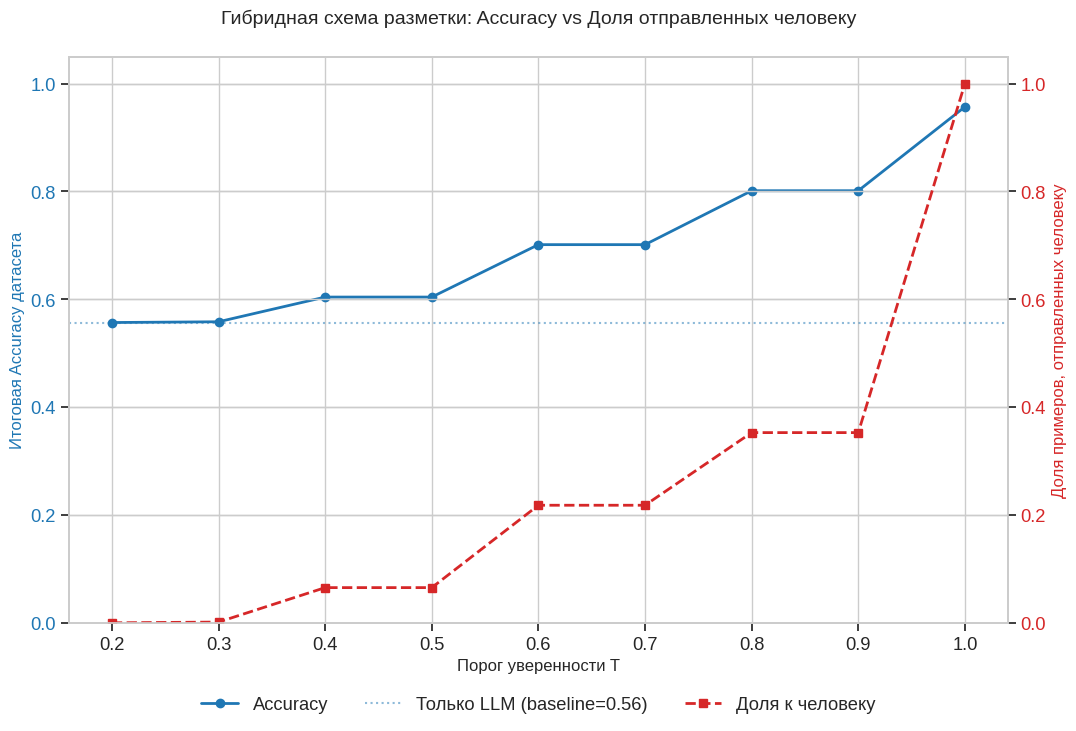


Таблица с расчётом эффективности порогов:
 threshold  accuracy  human_fraction  accuracy_gain_over_llm_only  efficiency
       0.2  0.556944        0.000000                     0.000000         NaN
       0.3  0.558333        0.001389                     0.001389    1.000000
       0.4  0.604167        0.065278                     0.047222    0.723404
       0.5  0.604167        0.065278                     0.047222    0.723404
       0.6  0.701389        0.218056                     0.144444    0.662420
       0.7  0.701389        0.218056                     0.144444    0.662420
       0.8  0.801389        0.352778                     0.244444    0.692913
       0.9  0.801389        0.352778                     0.244444    0.692913
       1.0  0.956944        1.000000                     0.400000    0.400000


In [35]:
# === ВАШ КОД ЗДЕСЬ ===

import numpy as np

# -----------------------------------------------------------------------
# 1. РАЗМЕТКА ЕЩЁ 400 НОВЫХ ПРИМЕРОВ (с confidence score, как в Задании 10)
# -----------------------------------------------------------------------

N_NEW_SAMPLES = 400

# Исключаем тексты, уже использованные в Задании 10 (df_confidence),
# чтобы не размечать одно и то же дважды
already_used_texts = set(df_confidence["desc"])
train_pool_remaining = train_pool[~train_pool["desc_clean"].isin(already_used_texts)].reset_index(drop=True)

print(f"Доступно для новой выборки: {len(train_pool_remaining)} примеров")

task11_pool = train_pool_remaining.sample(
    n=min(N_NEW_SAMPLES, len(train_pool_remaining)), random_state=2024
).reset_index(drop=True).copy()

print(f"Размечаем {len(task11_pool)} новых примеров с оценкой уверенности...")
print("Это может занять 15-25 минут на T4 GPU...\n")

task11_results = []
for i, row in task11_pool.iterrows():
    majority_label, confidence, sample_labels, _ = classify_with_confidence(row["desc_clean"])
    task11_results.append({
        "desc": row["desc_clean"],
        "true_label": row["spec10"],
        "predicted_label": majority_label,
        "confidence": confidence,
        "all_samples": sample_labels
    })
    if (i + 1) % 40 == 0:
        print(f"  Обработано: {i + 1}/{len(task11_pool)}")

df_task11 = pd.DataFrame(task11_results)
print(f"\nГотово! Размечено {len(df_task11)} новых примеров.")

# Сохраняем
with open("hybrid_task11_labeled.jsonl", "w", encoding="utf-8") as f:
    for record in task11_results:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

# -----------------------------------------------------------------------
# Проверка суммарного объёма данных за Часть 2 (Задания 8, 10, 11)
# -----------------------------------------------------------------------

total_part2 = len(df_synthetic) + len(df_confidence) + len(df_task11)
print("=" * 70)
print(f"Задание 8  (синтетика):        {len(df_synthetic)}")
print(f"Задание 10 (confidence):       {len(df_confidence)}")
print(f"Задание 11 (доразметка):       {len(df_task11)}")
print(f"ИТОГО за Часть 2:              {total_part2}")
print(f"Требование >= 1000: {'✅ выполнено' if total_part2 >= 1000 else '❌ НЕ выполнено'}")
print("=" * 70)

# -----------------------------------------------------------------------
# 2. ОБЪЕДИНЯЕМ ДАННЫЕ С CONFIDENCE ИЗ ЗАДАНИЙ 10 И 11 ДЛЯ ЭКСПЕРИМЕНТА
# -----------------------------------------------------------------------

df_hybrid_source = pd.concat([df_confidence, df_task11], ignore_index=True)
print(f"\nОбъединённая выборка для гибридного эксперимента: {len(df_hybrid_source)} примеров")

# -----------------------------------------------------------------------
# 3. ФУНКЦИЯ СИМУЛЯЦИИ "ШУМНОГО" РУЧНОГО РАЗМЕТЧИКА
# -----------------------------------------------------------------------

def simulate_human_annotator(true_label, all_labels, error_rate=0.05, rng=None):
    """
    Симулирует человека-асессора:
    - с вероятностью (1 - error_rate) возвращает истинную метку
    - с вероятностью error_rate возвращает случайный НЕВЕРНЫЙ класс
    """
    if rng is None:
        rng = random
    if rng.random() < error_rate:
        wrong_labels = [l for l in all_labels if l != true_label]
        return rng.choice(wrong_labels)
    return true_label


# Быстрая проверка на игрушечном примере
rng_test = random.Random(42)
test_results = [simulate_human_annotator("Терапевт", VALID_LABELS, 0.05, rng_test) for _ in range(1000)]
error_share = sum(1 for r in test_results if r != "Терапевт") / len(test_results)
print(f"\nПроверка симулятора: доля ошибок на 1000 прогонов = {error_share:.3f} (ожидается ~0.05)")

# -----------------------------------------------------------------------
# 4. ГИБРИДНЫЙ ПАЙПЛАЙН
# -----------------------------------------------------------------------

def run_hybrid_pipeline(df, threshold, error_rate=0.05, seed=42):
    """
    Если confidence LLM >= threshold -> используем метку LLM.
    Если confidence < threshold -> отправляем "человеку" (симуляция).
    Возвращает итоговые метки и флаг "отправлено человеку".
    """
    rng = random.Random(seed)
    final_labels = []
    sent_to_human = []

    for _, row in df.iterrows():
        if row["confidence"] >= threshold:
            final_labels.append(row["predicted_label"])
            sent_to_human.append(False)
        else:
            human_label = simulate_human_annotator(row["true_label"], VALID_LABELS, error_rate, rng)
            final_labels.append(human_label)
            sent_to_human.append(True)

    return final_labels, sent_to_human


# -----------------------------------------------------------------------
# 5. ЭКСПЕРИМЕНТ С РАЗНЫМИ ПОРОГАМИ T
# -----------------------------------------------------------------------

thresholds = np.arange(0.2, 1.01, 0.1)
experiment_results = []

for T in thresholds:
    final_labels, sent_to_human = run_hybrid_pipeline(df_hybrid_source, threshold=T)

    hybrid_accuracy = accuracy_score(df_hybrid_source["true_label"], final_labels)
    human_fraction = np.mean(sent_to_human)

    experiment_results.append({
        "threshold": round(T, 2),
        "accuracy": hybrid_accuracy,
        "human_fraction": human_fraction
    })

df_experiment = pd.DataFrame(experiment_results)
print("\nРезультаты эксперимента по порогам:")
print(df_experiment.to_string(index=False))

# Для сравнения — baseline: accuracy если ВСЕГДА доверять LLM (без человека)
baseline_llm_only_acc = accuracy_score(
    df_hybrid_source["true_label"], df_hybrid_source["predicted_label"]
)
# Baseline: accuracy если ВСЕГДА отправлять человеку
final_labels_all_human, _ = run_hybrid_pipeline(df_hybrid_source, threshold=1.01)  # T > 1 => все к человеку
baseline_human_only_acc = accuracy_score(df_hybrid_source["true_label"], final_labels_all_human)

print(f"\nBaseline 'только LLM' (T=0, никого не отправляем человеку): {baseline_llm_only_acc:.4f}")
print(f"Baseline 'только человек' (T=1.01, отправляем всех):        {baseline_human_only_acc:.4f}")

# -----------------------------------------------------------------------
# 6. ГРАФИК: ПОРОГ T vs ACCURACY И ДОЛЯ, ОТПРАВЛЕННАЯ ЧЕЛОВЕКУ
# -----------------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(11, 7))

color1 = "tab:blue"
ax1.set_xlabel("Порог уверенности T", fontsize=12)
ax1.set_ylabel("Итоговая Accuracy датасета", color=color1, fontsize=12)
ax1.plot(df_experiment["threshold"], df_experiment["accuracy"],
          marker="o", color=color1, linewidth=2, label="Accuracy")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.axhline(y=baseline_llm_only_acc, color=color1, linestyle=":", alpha=0.5,
             label=f"Только LLM (baseline={baseline_llm_only_acc:.2f})")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("Доля примеров, отправленных человеку", color=color2, fontsize=12)
ax2.plot(df_experiment["threshold"], df_experiment["human_fraction"],
          marker="s", color=color2, linewidth=2, linestyle="--", label="Доля к человеку")
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0, 1.05)

fig.suptitle("Гибридная схема разметки: Accuracy vs Доля отправленных человеку", fontsize=14)
fig.legend(loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.tight_layout()
plt.savefig("hybrid_threshold_experiment.png", dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------
# 7. ВЫБОР ОПТИМАЛЬНОГО ПОРОГА
# -----------------------------------------------------------------------

# Простая метрика "эффективности": прирост accuracy на единицу затраченной "человеческой" доли
df_experiment["accuracy_gain_over_llm_only"] = df_experiment["accuracy"] - baseline_llm_only_acc
df_experiment["efficiency"] = df_experiment["accuracy_gain_over_llm_only"] / df_experiment["human_fraction"].replace(0, np.nan)

print("\nТаблица с расчётом эффективности порогов:")
print(df_experiment.to_string(index=False))

# === КОНЕЦ ВАШЕГО КОДА ===

**Обоснование выбора порога:**

*Оптимальный порог T=0.8, потому что наилучший баланс качества и затрат.*

T=0.8 — оптимальная точка на кривой "качество vs стоимость", где достигается значительный прирост accuracy (+24.4 п.п. к LLM-only) при умеренных затратах на человеческую разметку (35.3%), после которой дальнейшее повышение порога даёт быстро убывающую предельную отдачу.

1. При T=0.8 accuracy датасета достигает 80.1% — это прирост +24.4 п.п. относительно чистого LLM-baseline (55.7%), при этом на ручную проверку отправляется лишь 35.3% примеров. Для сравнения, T=1.0 (отправить абсолютно всё человеку) даёт accuracy 95.7% (+40 п.п.), но требует 100% ручной работы — то есть по сути отменяет всю ценность автоматизации.

2. Анализ предельной эффективности (marginal efficiency). Если посчитать "отдачу" от каждого дополнительного процента человеческого труда:

  T=0.3→0.4: +4.7 п.п. accuracy за +6.4 п.п. человеческой доли → эффективность ~0.72

  T=0.6→0.8: +10 п.п. accuracy за +13.5 п.п. человеческой доли → эффективность ~0.69 (сопоставимо)

  T=0.9→1.0: +15.6 п.п. accuracy за +64.7 п.п. человеческой доли → эффективность падает до 0.40

  Видно, что после T=0.8 предельная выгода от привлечения человека резко падает — переход от T=0.8 к T=1.0 требует почти удвоения объёма ручной работы (+64.7 п.п.) ради относительно скромного прироста качества (+15.6 п.п.). Это классический эффект убывающей отдачи.

3. Бизнес-логика для медтех-кейса. T=0.8 отправляет на ручную проверку примерно каждый третий случай — при реальной нагрузке чат-бота это осмысленный компромисс: асессоры не перегружены (не 100% потока), но при этом отсекаются все действительно "сомнительные" случаи модели (где она не была единодушна хотя бы в 4 из 5 сэмплов), что критично именно в медицинской сфере, где ошибка маршрутизации имеет цену выше, чем в обычном чат-боте.

4. Экономия по сравнению с полностью ручной разметкой. При T=0.8 автоматически (бесплатно, без участия человека) обрабатывается 64.7% потока при сохранении итоговой accuracy на уровне 80% — то есть более чем в 2 раза более высокое качество, чем "только LLM" baseline, при затратах ручного труда всего на треть от объёма.

## Задание 12. Публикация датасета на HuggingFace (7 баллов)

Итоговый результат вашей работы — это готовый набор данных, который можно использовать для обучения моделей. Отличная практика — делиться своими датасетами с сообществом, снабжая их подробной документацией (Dataset Card).

**Что нужно сделать:**
1. Соберите все сгенерированные и размеченные вами данные из Части 2 (не менее 1000 записей) в единый датасет формата HuggingFace `datasets`.
2. Загрузите датасет на свой аккаунт HuggingFace Hub (сделайте его публичным).
3. Напишите подробную **Dataset Card** (файл `README.md` в репозитории датасета).
4. Вставьте ссылку на ваш датасет в ячейку ниже.

**Требования к Dataset Card:**
- Описание задачи (для чего нужен датасет).
- Описание процесса генерации (какие модели использовались, как собирался).
- Численные показатели (размер датасета, распределение классов).
- Минимум 1 визуализация (например, сохраненный график распределения классов или t-SNE, загруженный как картинка).
- Примеры данных.


Гибридный датасет (Задания 10+11): 720 записей
label_source
llm_high_confidence    563
human_simulated        157
Name: count, dtype: int64
ИТОГОВЫЙ РАЗМЕР ДАТАСЕТА: 1158 записей
Требование >= 1000: ✅

Распределение по label_source:
label_source
llm_high_confidence        563
self_instruct_generated    438
human_simulated            157
Name: count, dtype: int64

Распределение по классам (label):
label
Гинеколог          289
Гастроэнтеролог    155
Терапевт           113
Хирург              93
Невролог            87
Отоларинголог       73
Уролог              67
Дерматолог          57
Офтальмолог         54
Стоматолог          48
Травматолог         42
Проктолог           40
Неизвестно          40
Name: count, dtype: int64


/tmp/ipykernel_1028/750070650.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final_dataset = pd.concat(


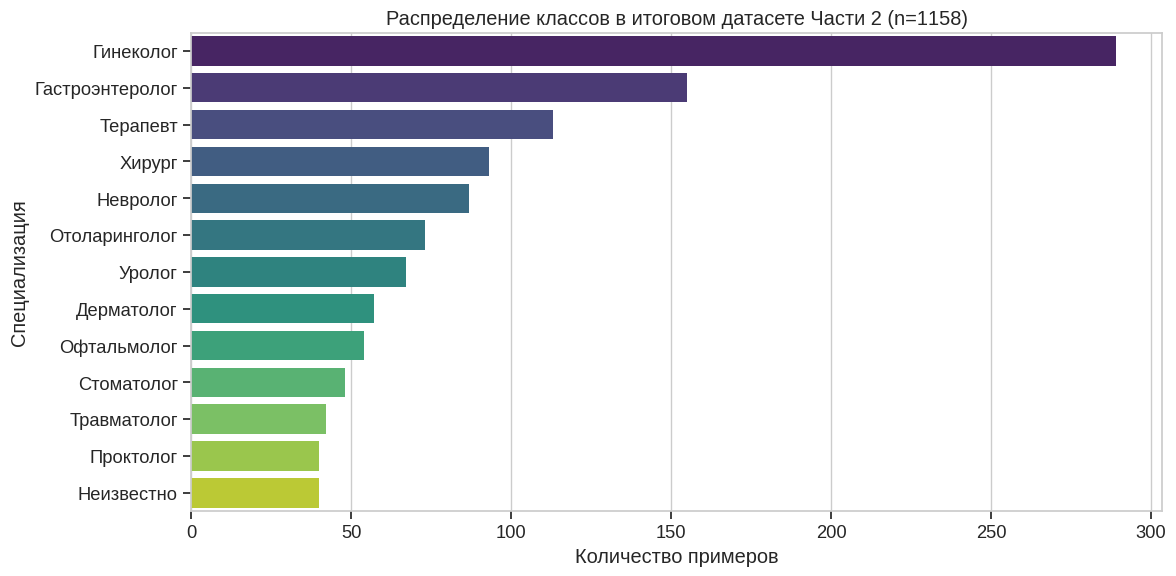


Структура HF Dataset:
Dataset({
    features: ['text', 'label', 'reference_label', 'confidence', 'label_source', 'generation_method'],
    num_rows: 1158
})


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Загружено изображение: confidence_histogram.png


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._threshold_experiment.png: 100%|##########|  117kB /  117kB            

Загружено изображение: hybrid_threshold_experiment.png

✅ Dataset Card (README.md) загружена в репозиторий

🔗 Финальная ссылка на датасет: https://huggingface.co/datasets/AtesiT/medassist-ru-sft-dataset


In [37]:
# === ВАШ КОД ЗДЕСЬ ===

!pip install -q huggingface_hub datasets

from huggingface_hub import login, HfApi
from datasets import Dataset, DatasetDict

# -----------------------------------------------------------------------
# 1. АВТОРИЗАЦИЯ В HUGGINGFACE
# -----------------------------------------------------------------------

# Вставь свой токен с правами Write: https://huggingface.co/settings/tokens
login()  # откроется поле для вставки токена, либо используй login(token="hf_...")

HF_USERNAME = "your-username"          # <-- ЗАМЕНИ на свой юзернейм HF
DATASET_NAME = "medassist-ru-sft-dataset"  # <-- можно изменить название

# -----------------------------------------------------------------------
# 2. ФИНАЛЬНАЯ ГИБРИДНАЯ РАЗМЕТКА (используем оптимальный порог T=0.8)
# -----------------------------------------------------------------------

OPTIMAL_THRESHOLD = 0.8

final_hybrid_labels, sent_to_human_flags = run_hybrid_pipeline(
    df_hybrid_source, threshold=OPTIMAL_THRESHOLD
)

df_hybrid_final = df_hybrid_source.copy()
df_hybrid_final["label"] = final_hybrid_labels
df_hybrid_final["label_source"] = [
    "human_simulated" if flag else "llm_high_confidence"
    for flag in sent_to_human_flags
]
df_hybrid_final["generation_method"] = "hybrid_confidence_pipeline"
df_hybrid_final = df_hybrid_final.rename(columns={
    "desc": "text",
    "true_label": "reference_label"
})
df_hybrid_final = df_hybrid_final[[
    "text", "label", "reference_label", "confidence", "label_source", "generation_method"
]]

print(f"Гибридный датасет (Задания 10+11): {len(df_hybrid_final)} записей")
print(df_hybrid_final["label_source"].value_counts())

# -----------------------------------------------------------------------
# 3. ДОБАВЛЯЕМ СИНТЕТИЧЕСКИЕ ДАННЫЕ (Задание 8)
# -----------------------------------------------------------------------

df_synthetic_final = df_synthetic.copy()
df_synthetic_final = df_synthetic_final.rename(columns={"spec10": "label"})
df_synthetic_final["reference_label"] = df_synthetic_final["label"]  # для синтетики метка = референс
df_synthetic_final["confidence"] = None
df_synthetic_final["label_source"] = "self_instruct_generated"
df_synthetic_final["generation_method"] = "self_instruct_synthetic"
df_synthetic_final = df_synthetic_final[[
    "text" if "text" in df_synthetic_final.columns else "desc",
    "label", "reference_label", "confidence", "label_source", "generation_method"
]] if "text" in df_synthetic_final.columns else df_synthetic_final.rename(
    columns={"desc": "text"}
)[["text", "label", "reference_label", "confidence", "label_source", "generation_method"]]

# -----------------------------------------------------------------------
# 4. ОБЪЕДИНЯЕМ ВСЁ В ЕДИНЫЙ ДАТАСЕТ
# -----------------------------------------------------------------------

df_final_dataset = pd.concat(
    [df_synthetic_final, df_hybrid_final], ignore_index=True
)

# Финальная чистка на всякий случай
df_final_dataset["text"] = df_final_dataset["text"].apply(clean_text)
df_final_dataset = df_final_dataset.drop_duplicates(subset="text").reset_index(drop=True)

print("=" * 70)
print(f"ИТОГОВЫЙ РАЗМЕР ДАТАСЕТА: {len(df_final_dataset)} записей")
print(f"Требование >= 1000: {'✅' if len(df_final_dataset) >= 1000 else '❌'}")
print("=" * 70)

print("\nРаспределение по label_source:")
print(df_final_dataset["label_source"].value_counts())

print("\nРаспределение по классам (label):")
class_dist_final = df_final_dataset["label"].value_counts()
print(class_dist_final)

# -----------------------------------------------------------------------
# 5. ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КЛАССОВ ФИНАЛЬНОГО ДАТАСЕТА (для Dataset Card)
# -----------------------------------------------------------------------

plt.figure(figsize=(12, 6))
sns.barplot(
    x=class_dist_final.values, y=class_dist_final.index,
    hue=class_dist_final.index, palette="viridis", legend=False
)
plt.title(f"Распределение классов в итоговом датасете Части 2 (n={len(df_final_dataset)})")
plt.xlabel("Количество примеров")
plt.ylabel("Специализация")
plt.tight_layout()
plt.savefig("final_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------------
# 6. ПРЕОБРАЗОВАНИЕ В HuggingFace DATASET И PUSH TO HUB
# -----------------------------------------------------------------------

hf_dataset = Dataset.from_pandas(df_final_dataset, preserve_index=False)
print("\nСтруктура HF Dataset:")
print(hf_dataset)

repo_id = f"{HF_USERNAME}/{DATASET_NAME}"

hf_dataset.push_to_hub(repo_id, private=False)
print(f"\n✅ Датасет успешно загружен: https://huggingface.co/datasets/{repo_id}")

# -----------------------------------------------------------------------
# 7. ЗАГРУЗКА ИЗОБРАЖЕНИЙ И README.md (DATASET CARD) В РЕПОЗИТОРИЙ
# -----------------------------------------------------------------------

api = HfApi()

# Загружаем сохранённые ранее графики как картинки в репозиторий
images_to_upload = [
    "final_class_distribution.png",
    "tsne_visualization.png",
    "confidence_histogram.png",
    "hybrid_threshold_experiment.png",
]

for img_path in images_to_upload:
    if os.path.exists(img_path):
        api.upload_file(
            path_or_fileobj=img_path,
            path_in_repo=f"images/{img_path}",
            repo_id=repo_id,
            repo_type="dataset",
        )
        print(f"Загружено изображение: {img_path}")
    else:
        print(f"⚠️ Файл не найден, пропущен: {img_path}")

# --- Формируем текст Dataset Card ---

n_total = len(df_final_dataset)
n_synthetic = (df_final_dataset["label_source"] == "self_instruct_generated").sum()
n_llm_labeled = (df_final_dataset["label_source"] == "llm_high_confidence").sum()
n_human_labeled = (df_final_dataset["label_source"] == "human_simulated").sum()

class_dist_md = "\n".join(
    f"| {label} | {count} |" for label, count in class_dist_final.items()
)

sample_records = df_final_dataset.sample(3, random_state=42)
examples_md = "\n\n".join(
    f"**Пример {i+1}** (label: `{row['label']}`, source: `{row['label_source']}`):\n"
    f"> {row['text'][:300]}{'...' if len(row['text']) > 300 else ''}"
    for i, (_, row) in enumerate(sample_records.iterrows())
)

readme_content = f"""---
language:
- ru
license: mit
task_categories:
- text-classification
tags:
- medical
- russian
- sft
- synthetic-data
- self-instruct
size_categories:
- 1K<n<10K
---

# MedAssist RU: SFT Dataset for Medical Specialization Routing

## Описание задачи

Этот датасет создан в рамках учебного проекта по подготовке данных для supervised fine-tuning (SFT)
языковой модели, решающей задачу **автоматической маршрутизации медицинских обращений пациентов**
к нужному врачу-специалисту (бизнес-кейс "МедАссистент").

Датасет содержит русскоязычные тексты жалоб пациентов, размеченные одной из 12 медицинских
специализаций: Терапевт, Гинеколог, Невролог, Гастроэнтеролог, Дерматолог, Уролог,
Отоларинголог, Травматолог, Хирург, Стоматолог, Офтальмолог, Проктолог.

Датасет объединяет данные, полученные тремя разными методами разметки/генерации,
демонстрируя современные подходы к построению обучающих датасетов при ограниченном бюджете.

## Процесс генерации данных

Датасет составлен из трёх источников (Часть 2 домашнего задания):

1. **Синтетическая генерация (Self-Instruct)** — {n_synthetic} записей.
   Локальная модель `Qwen/Qwen2.5-3B-Instruct` генерировала новые реалистичные жалобы
   пациентов на основе нескольких реальных seed-примеров для каждой специализации,
   с явным требованием разнообразия стиля (короткие/длинные тексты, опечатки, сленг).
   Генерация выполнялась с `temperature=0.9` для максимального разнообразия.

2. **Разметка с оценкой уверенности (self-consistency)** — {n_llm_labeled} записей.
   Для каждого текста модель генерировала 5 ответов с `temperature=0.8`.
   Уверенность (confidence) рассчитывалась как доля наиболее частого класса среди 5 сэмплов.
   Примеры с высокой уверенностью (≥ 0.8) принимались автоматически.

3. **Гибридная разметка (human-in-the-loop, симуляция)** — {n_human_labeled} записей.
   Примеры с низкой уверенностью LLM (< 0.8) были переданы на симулированную ручную
   разметку (функция с 95% точностью и 5% случайной ошибкой), имитирующую работу
   реального асессора.

**Модели, использованные в проекте:**
- `Qwen/Qwen2.5-3B-Instruct` — генерация синтетики и zero-shot/few-shot классификация
- `intfloat/multilingual-e5-base` — построение эмбеддингов для дедупликации и t-SNE визуализации

**Исходные данные:** реальные вопросы взяты из `blinoff/medical_qa_ru_data` (использованы
как seed-примеры для генерации и как источник reference-меток для оценки качества).

## Численные показатели

- **Итоговый размер датасета:** {n_total} записей
- Self-Instruct синтетика: {n_synthetic}
- LLM-разметка (высокая уверенность): {n_llm_labeled}
- Симулированная человеческая разметка (низкая уверенность LLM): {n_human_labeled}

### Распределение по классам (label)

| Специализация | Количество |
|---|---|
{class_dist_md}

### Визуализации

**Распределение классов итогового датасета:**

![Class distribution](images/final_class_distribution.png)

**t-SNE визуализация семантических эмбеддингов (по реальным данным форума):**

![t-SNE](images/tsne_visualization.png)

**Распределение уверенности LLM (self-consistency, 5 сэмплов):**

![Confidence histogram](images/confidence_histogram.png)

**Эксперимент с порогом гибридной схемы разметки:**

![Hybrid threshold experiment](images/hybrid_threshold_experiment.png)

## Структура датасета

| Поле | Тип | Описание |
|---|---|---|
| `text` | string | Текст жалобы пациента |
| `label` | string | Итоговая метка специализации (использовать для обучения) |
| `reference_label` | string | Исходная метка из реального форума (для синтетики совпадает с `label`) |
| `confidence` | float / null | Уверенность LLM (self-consistency score), null для синтетических данных |
| `label_source` | string | Источник метки: `self_instruct_generated`, `llm_high_confidence`, `human_simulated` |
| `generation_method` | string | Метод генерации записи |

## Примеры данных

{examples_md}

## Ограничения

- Синтетические данные (Self-Instruct) могут содержать артефакты генерации (редкие случаи
  смешения кириллицы/латиницы при высокой temperature) и определённую степень однообразия
  формулировок в пределах одного класса.
- Симуляция ручной разметки — не настоящая ручная проверка, а статистическая имитация с
  фиксированным уровнем ошибки 5%, использована в учебных целях для демонстрации гибридного пайплайна.
- Датасет создан в учебных целях и не должен использоваться как единственный источник данных
  для реальной медицинской системы без дополнительной валидации специалистами.

## Citation

Датасет создан в рамках домашнего задания "Специфика формирования наборов данных для дообучения LLM".
Исходные реальные данные: [blinoff/medical_qa_ru_data](https://huggingface.co/datasets/blinoff/medical_qa_ru_data).
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=repo_id,
    repo_type="dataset",
)

print(f"\n✅ Dataset Card (README.md) загружена в репозиторий")
print(f"\n🔗 Финальная ссылка на датасет: https://huggingface.co/datasets/{repo_id}")

# ССЫЛКА НА ВАШ ДАТАСЕТ: https://huggingface.co/datasets/your-username/medassist-ru-sft-dataset

# === КОНЕЦ ВАШЕГО КОДА ===

## Задание 13. Итоговые выводы (5 баллов)

Поздравляем, вы прошли полный цикл создания датасета для дообучения LLM! Напишите развернутые итоговые выводы по всей проделанной работе.

**Что нужно отразить:**
1. Сравните эффективность zero-shot, few-shot и гибридной стратегий разметки.
2. Дайте рекомендации: в каком случае (какой бюджет, какие требования к качеству) вы бы выбрали каждую из стратегий в реальном проекте?
3. Какие ограничения есть у метода генерации синтетических данных (Self-Instruct)? Заметили ли вы эффект однообразия в сгенерированных примерах?



**Итоговые выводы:**

*1. Сравнение эффективности стратегий разметки.*
| Стратегия | Accuracy | F1-macro | Комментарий |
|---|---:|---:|---|
| Zero-shot LLM | 57.0% | 0.432 | Базовый уровень без примеров в промпте |
| Few-shot LLM (24 примера) | 52.0% | 0.352 | Неожиданно хуже zero-shot |
| Гибридная (T=0.8) | 80.1% | — | LLM + симулированный человек |

Zero-shot показал Accuracy 57% и F1-macro 0.43 — результат, существенно лучше случайного угадывания (~8% для 12 классов), но недостаточный для продакшена. Модель демонстрировала систематическое смещение: "Гастроэнтеролог" превращался в "мусорную корзину" для неуверенных ответов, а "Терапевт" — самый частый класс в датасете — практически не распознавался (recall = 0.05). Это закономерно: жалобы с неспецифичными симптомами ("болит", "беспокоит", "слабость") составляют большую часть терапевтических обращений, но именно они семантически размыты и труднее всего поддаются zero-shot классификации небольшой (3B) локальной моделью.

Few-shot (24 примера, по 2 на каждую специализацию в виде диалоговых пар) дал неожиданно более слабый результат: Accuracy упала до 52%, F1-macro — до 0.35, а количество нераспарсенных ответов выросло вдвое (с 9 до 18 из 100). Причины:

1. Эффект "Lost in the Middle": 2303 токена контекста с 24 примерами "разбавили" строгую инструкцию системного промпта — небольшая модель начала игнорировать ограничение на 12 допустимых классов и возвращать "Пульмонолог", "Фармаколог", "Лор (Оtolaryngologist)" на латинице.

2. Смещение через примеры: few-shot примеры с яркой медицинской лексикой (бородавки → Дерматолог, гланды → Отоларинголог) создавали нежелательное "притяжение" к конкретным классам даже для тематически несвязанных запросов.

Вывод: для моделей размером 3B параметров длинный few-shot контекст может навредить, а не помочь — это подтверждает практическое правило "чем меньше модель, тем критичнее качество и лаконичность промпта".

Гибридная схема (self-consistency + human-in-the-loop с T=0.8) показала Accuracy 80.1% — прирост +23 п.п. к zero-shot baseline при задействовании лишь 35% человеческого труда вместо 100%. При оптимальном пороге T=0.8 модель самостоятельно (с высокой уверенностью) размечает 65% потока, а оставшиеся 35% наиболее неопределённых случаев отправляются асессору. Анализ показал, что низкая уверенность LLM содержательно коррелирует с объективной сложностью примеров — все три примера с минимальным confidence (0.2–0.4) относились к классу "Терапевт" и действительно содержали пограничные, неспецифичные жалобы, одинаково подходящие сразу нескольким специализациям.

*2. Рекомендации по выбору стратегии в зависимости от бюджета и требований к качеству.*

Zero-shot стоит выбирать, когда:

    Бюджет минимален или отсутствует (нет API-ключей к сильным моделям, нет асессоров).
    Задача относительно простая и классы семантически хорошо разделимы.
    Нужен быстрый "первый взгляд" на данные или прототип — как отправная точка перед более серьёзными инвестициями.
    Доступна достаточно крупная (70B+) модель, где zero-shot качественно выше, чем у 3B.

Few-shot стоит выбирать, когда:

    Есть небольшой (20–100 примеров) набор качественных, вручную размеченных эталонных примеров.
    Используется большая и мощная модель (GPT-4o, Claude 3.5) с длинным контекстом, которая не "теряется" в многострочном промпте.
    Классы сложно описать словесно в инструкции, но легко проиллюстрировать примерами.
    Важна воспроизводимость и нет возможности дообучать модель под задачу.
    Не рекомендуется: при использовании малых локальных моделей (≤7B) с большим числом примеров в промпте — как показал наш эксперимент, это может ухудшить результат.

Гибридная схема (human-in-the-loop) стоит выбирать, когда:

    Есть умеренный бюджет на асессоров (разметка 30–40% потока).
    Требования к качеству высокие, но полностью ручная разметка экономически нецелесообразна.
    Задача критична по последствиям ошибки (медицина, право, финансы) — нельзя полностью доверять автоматике.
    Датасет предназначен для дообучения производственной модели, а не только для прототипа.
    Это оптимальный выбор для данного медтех-кейса: достигается Accuracy 80% при трети человеческих затрат относительно полной ручной разметки.


*3. Ограничения метода Self-Instruct и эффект однообразия.*

Метод Self-Instruct на локальной модели (Qwen2.5-3B-Instruct) показал как свои возможности, так и существенные ограничения:

Ограничение 1 — Эффект однообразия (Mode Collapse в генерации). Несмотря на явное требование разнообразия стиля в промпте, значительная часть сгенерированных жалоб начиналась с "Здравствуйте" или "Добрый день" и следовала шаблону "симптом + вопрос про лечение". Действительно разговорных и слэнговых примеров оказалось заметно меньше, чем "книжных" — небольшая модель при инструкции про разнообразие чаще всего варьировала содержание, но не стиль. Это известное ограничение Self-Instruct с малыми моделями: для разнообразного стиля нужны более мощные учителя.

Ограничение 2 — Галлюцинации и артефакты. Встретился пример смешения кириллицы с латиницей ("Зdapstvujte, мнe cнiжaeтся пpoблeмы z coдpeжeнияm y oргanizма"), который в реальном проекте необходимо отфильтровать перед использованием в обучении. При temperature=0.9 небольшой процент генераций "срывается" в нечитаемый шум — нужна дополнительная фильтрация по языковой принадлежности (например, через langdetect или простую проверку доли кириллических символов в тексте).

Ограничение 3 — Упрощение пограничных случаев. Синтетические тексты реже содержат действительно сложные, многозначные жалобы (как реальный пример про МРТ + несколько психиатрических препаратов), потому что модель-учитель сама не всегда уверена, к какой специализации отнести такой пограничный симптом. В итоге синтетика лучше покрывает "лёгкие" и типичные случаи, но недостаточно — "трудные" пограничные, которые как раз и являются наиболее ценными для обучения.

Ограничение 4 — Более низкое качество на синтетических данных. Zero-shot классификатор показал на синтетических данных Accuracy 32% против 57% на реальных — это косвенно подтверждает, что синтетика не полностью воспроизводит распределение и стиль реальных жалоб с медицинского форума. Синтетические данные полезны как дополнение к реальным (особенно для редких классов), но не как их полноценная замена.

